# Analysis of mutational characteristics in Paralog Region of Mtb genome

### This analysis looks at:
1) SNP clustering (Inter-SNP distance)
2) Enrichment for paralog matching subsitutions
3) Mutational Signature analysis of PRs versus non-PR regions of the Mtb genome
4) rainfail plots for inter-SNP distance
5) Other related analyses

# Import Statements (libraries + Functions)

In [131]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [132]:
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [133]:
#import scipy.stats
#import scipy.stats as stats
#from statsmodels.stats.proportion import proportions_ztest


In [134]:
import bioframe as bf

In [135]:
# import matplotlib
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42

In [136]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [137]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

In [138]:
import matplotlib.patches as mpatches


#### Pandas Viewing Settings

In [139]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Define Rainfall viz functions

In [140]:
import matplotlib.pyplot as plt

def plot_snp_rainfall_region(df, chrom, start_bp, end_bp, flank_bp=0):
    """
    Plot SNP rainfall for a region [start_bp - flank_bp, end_bp + flank_bp] on a given chromosome.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing columns 'Chrom', 'Start_0', 'DistToNearestSNP', and 'RegionType'.
    chrom : str
        Chromosome name (e.g., 'NC_000962.3').
    start_bp : int
        Region start coordinate.
    end_bp : int
        Region end coordinate.
    flank_bp : int, optional
        Amount of flanking sequence (in bp) to include on each side. Default is 0.

    Returns
    -------
    matplotlib.figure.Figure
        The rainfall plot figure object.
    """
    sub = df[
        (df["Chrom"] == chrom)
        & (df["Start_0"] >= (start_bp - flank_bp))
        & (df["Start_0"] <= (end_bp + flank_bp))
    ].copy()

    sub = sub[sub["DistToNearestSNP"] > 0]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.scatter(
        sub["Start_0"].values,
        sub["DistToNearestSNP"].values,
        s=14,
        alpha=0.3,
        c=sub["RegionType"].map({"Unq": "red", "PR": "blue"}).fillna("gray").values,
    )
    ax.set_xlim(start_bp - flank_bp, end_bp + flank_bp)
    ax.set_yscale("log")
    ax.set_xlabel(f"Genomic position (bp) on {chrom}")
    ax.set_ylabel("Inter-SNP distance (bp, log10 scale)")
    ax.set_title(f"SNP Rainfall: {chrom}:{start_bp - flank_bp}-{end_bp + flank_bp}")
    fig.tight_layout()
    sns.despine()
    return fig

In [141]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter



def plot_snp_rainfall_region_V2(
    df, chrom, start_bp, end_bp, flank_bp=0, ax=None,
    point_size=14, alpha=0.3
):
    """
    Plot SNP rainfall for a region [start_bp - flank_bp, end_bp + flank_bp] on a given chromosome.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with columns 'Chrom', 'Start_0', 'DistToNearestSNP', and 'RegionType'.
    chrom : str
        Chromosome name (e.g., 'NC_000962.3').
    start_bp : int
        Region start coordinate.
    end_bp : int
        Region end coordinate.
    flank_bp : int, optional
        Amount of flanking sequence (bp) on each side. Default is 0.
    ax : matplotlib.axes.Axes, optional
        Axis to plot onto. If None, a new figure and axis are created.
    point_size : int, optional
        Size of scatter points.
    alpha : float, optional
        Transparency level for points.

    Returns
    -------
    matplotlib.figure.Figure or (matplotlib.figure.Figure, matplotlib.axes.Axes)
        If ax is None, returns (fig, ax); otherwise, returns the provided ax.
    """
    sub = df[
        (df["Chrom"] == chrom)
        & (df["Pos_0based"] >= (start_bp - flank_bp))
        & (df["Pos_0based"] <= (end_bp + flank_bp))
    ].copy()
    #sub = sub[sub["InterMutDist_ASR"] >= 0]

    # Create new fig/ax if needed
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))
        created_fig = True
    else:
        fig = ax.figure

    colors = sub["RegionType"].map({"Unq": "red", "PR": "blue"}).fillna("gray").values

    ax.scatter(
        sub["Pos_0based"].values,
        sub["InterMutDist_ASR"].values,
        s=point_size,
        alpha=alpha,
        c=colors,
    )
    ax.set_xlim(start_bp - flank_bp, end_bp + flank_bp)
    ax.set_yscale("log")
    ax.set_xlabel(f"Genomic position (bp) on {chrom}")
    ax.set_ylabel("Inter-SNP distance (bp, log10 scale)\n Per SNP Mutation Event")
    #ax.set_title(f"SNP Rainfall: {chrom}:{start_bp - flank_bp}-{end_bp + flank_bp}")
    ax.spines[['top', 'right']].set_visible(False)

    # Format axes to show full numbers (no scientific notation)
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.ticklabel_format(style='plain', axis='x')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.ticklabel_format(style='plain', axis='y')

    sns.despine()
    if created_fig:
        fig.tight_layout()
        return fig, ax
    else:
        return None, ax


In [142]:
GENOME_LEN = 4_411_532  # H37Rv

def compute_windowed_intersnp_distance(df, chrom, start_bp, end_bp, window_bp=100, agg="median"):
    
    sub = df[(df["Chrom"] == chrom) & (df["Pos_0based"] >= start_bp) & (df["Pos_0based"] <= end_bp)].copy()
    sub = sub[sub["InterMutDist_ASR"] >= 0]
    
    edges = np.arange(start_bp, end_bp + window_bp, window_bp, dtype=int)
    
    # Assign bins
    bin_idx = np.clip(((sub["Pos_0based"].values - start_bp) // window_bp).astype(int), 0, max(0, len(edges)-2))
    sub = sub.assign(__bin=bin_idx)
    
    # Aggregate
    if agg == "mean":
        agg_series = sub.groupby("__bin")["InterMutDist_ASR"].mean()
    else:
        agg_series = sub.groupby("__bin")["InterMutDist_ASR"].median()
        
    counts = sub.groupby("__bin")["InterMutDist_ASR"].size()
    
    # Build dense frame for all bins
    df_bins = pd.DataFrame({"__bin": np.arange(max(0, len(edges)-1))})
    df_bins["window_start"] = start_bp + df_bins["__bin"] * window_bp
    df_bins["window_end"] = df_bins["window_start"] + window_bp
    df_bins["mid_bp"] = (df_bins["window_start"] + df_bins["window_end"]) // 2
    df_bins["agg_dist"] = df_bins["__bin"].map(agg_series.to_dict())
    df_bins["n_variants"] = df_bins["__bin"].map(counts.to_dict()).fillna(0).astype(int)
    return df_bins.drop(columns="__bin")

In [143]:
def compute_sliding_intersnp_distance(
    df, chrom, start_bp, end_bp, window_bp=10_000, step_bp=10, agg="median", drop_empty=True
):
    """
    Compute a sliding-window inter-mutation distance track by moving a fixed-size window
    along the genome with a user-defined step.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain 'Chrom', 'Pos_0based', and 'InterMutDist_ASR' columns.
    chrom : str
        Chromosome (e.g., 'NC_000962.3').
    start_bp, end_bp : int
        Genomic range to cover (inclusive).
    window_bp : int, default 10_000
        Window size in bp.
    step_bp : int, default 10
        Slide step in bp.
    agg : {'median','mean'}, default 'median'
        Aggregate function over 'InterMutDist_ASR' within each window.
    drop_empty : bool, default True
        If True, drop windows with zero variants; otherwise keep with NaN agg_dist.

    Returns
    -------
    pandas.DataFrame with columns:
      ['window_start','window_end','mid_bp','n_variants','agg_dist']
    """
    # Subset & clean
    sub = df[(df["Chrom"] == chrom) & (df["Pos_0based"] >= start_bp) & (df["Pos_0based"] <= end_bp)].copy()
    sub = sub[sub["InterMutDist_ASR"] >= 0]

    # Sort by position for searchsorted-based windowing
    sub = sub.sort_values("Pos_0based")
    pos = sub["Pos_0based"].to_numpy(dtype=np.int64, copy=False)
    vals = sub["InterMutDist_ASR"].to_numpy(dtype=float, copy=False)

    # Prepare window starts
    window_starts = np.arange(start_bp, end_bp - window_bp + 1, step_bp, dtype=np.int64)
    window_ends = window_starts + window_bp  # half-open [start, end)

    # For each window, find slice indices via searchsorted
    left_idx = np.searchsorted(pos, window_starts, side="left")
    right_idx = np.searchsorted(pos, window_ends, side="left")

    n = len(window_starts)
    agg_out = np.full(n, np.nan, dtype=float)
    counts = (right_idx - left_idx).astype(int)

    # Aggregate per window
    for i in range(n):
        if counts[i] == 0:
            continue
        window_vals = vals[left_idx[i]:right_idx[i]]
        if agg == "mean":
            agg_out[i] = float(np.mean(window_vals))
        else:
            agg_out[i] = float(np.median(window_vals))

    mid_bp = window_starts + (window_bp // 2)
    out = pd.DataFrame({
        "window_start": window_starts,
        "window_end": window_ends,
        "mid_bp": mid_bp,
        "n_variants": counts,
        "agg_dist": agg_out
    })

    if drop_empty:
        out = out[counts > 0].reset_index(drop=True)

    return out


## Functions for gene anno + Variant Viz


In [144]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_Anno_with_empty_bottom(
    Viz_Start: int,
    Viz_End: int,
    in_Genome_Graphic_Record,   # dna_features_viewer GraphicRecord (H37Rv)
    *,
    figsize: Tuple[float, float] = (9, 3.6),
    dpi: int = 180,
    height_ratios: Tuple[float, float] = (1.0, 4.0),
    genome_label_threshold: int = 5,
    top_title: Optional[str] = None,
    show_bottom_xlabel: bool = True,
    x_integer_ticks_nbins: int = 6,
    tight_layout: bool = True,
    genesToLabel = None,
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Make a two-panel canvas:
      - Top: H37Rv genome annotations over [Viz_Start, Viz_End]
      - Bottom: empty axis (pre-formatted) to overlay mutations/variants later

    Returns
    -------
    fig, {"Genome_Anno_ax": ax0, "Bottom_ax": ax1}
    """
    # Crop to window
    graphic_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    if genesToLabel != None:
        for feature in graphic_cropped.features:
            if feature.label not in genesToLabel:
                feature.label = None

    # Figure & axes
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=figsize, dpi=dpi,
        gridspec_kw={"height_ratios": height_ratios},
        sharex=False
    )

    # --- Top: genome annotations ---
    if hasattr(graphic_cropped, "plot"):
        graphic_cropped.plot(
            strand_in_label_threshold=genome_label_threshold,
            ax=ax_top,
        )
    ax_top.set_xlim(Viz_Start, Viz_End)
    ax_top.set_xticks([])
    ax_top.set_xlabel("")
    if top_title:
        ax_top.set_title(top_title, fontsize=10)

    # --- Bottom: leave empty but pre-format x-axis for the same window ---
    ax_bottom.set_xlim(Viz_Start, Viz_End)
    if show_bottom_xlabel:
        ax_bottom.set_xlabel("Genomic position (1-based)")
    # integer ticks, no scientific notation
    fmt = mticker.ScalarFormatter(useOffset=False)
    fmt.set_scientific(False)
    ax_bottom.xaxis.set_major_formatter(fmt)
    ax_bottom.ticklabel_format(style="plain", axis="x", useOffset=False)
    ax_bottom.xaxis.set_major_locator(mticker.MaxNLocator(nbins=x_integer_ticks_nbins, integer=True))
    # keep the bottom panel minimal
    for spine in ("left", "top", "right"):
        ax_bottom.spines[spine].set_visible(False)
    ax_bottom.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.35)

    if tight_layout:
        fig.tight_layout()

    return fig, {"Genome_Anno_ax": ax_top, "Bottom_ax": ax_bottom}


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [145]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [146]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [147]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [148]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


# Import and setup MusiCal variables

In [149]:
import musical

In [150]:
# Trinucleotide colors for the 96 dimensional mutation spectrum
colorPaletteTrinucleotides = [(0.33, 0.75, 0.98), # C>A
                              (0, 0, 0),          # C>G
                              (0.85, 0.25, 0.22), #C>T
                              (0.78, 0.78, 0.78), #T>A
                              (0.51, 0.79, 0.24), #T>C
                              (0.89, 0.67, 0.72)] #T>G

# Trinucleotide color dictionary
colorPaletteTrinucleotides_dict = {
    "C>A": (0.33, 0.75, 0.98),
    "C>G": (0, 0, 0),
    "C>T": (0.85, 0.25, 0.22),
    "T>A": (0.78, 0.78, 0.78),
    "T>C": (0.51, 0.79, 0.24),
    "T>G": (0.89, 0.67, 0.72)
}

In [151]:
# These references and code were copied from https://github.com/parklab/MuSiCal/blob/main/musical/utils.py
##################
# Useful globals #
##################

trinucleotides_C = ["ACA",
                    "ACC",
                    "ACG",
                    "ACT",
                    "CCA",
                    "CCC",
                    "CCG",
                    "CCT",
                    "GCA",
                    "GCC",
                    "GCG",
                    "GCT",
                    "TCA",
                    "TCC",
                    "TCG",
                    "TCT"]

trinucleotides_T = ["ATA",
                    "ATC",
                    "ATG",
                    "ATT",
                    "CTA",
                    "CTC",
                    "CTG",
                    "CTT",
                    "GTA",
                    "GTC",
                    "GTG",
                    "GTT",
                    "TTA",
                    "TTC",
                    "TTG",
                    "TTT"]

snv_types_6_str = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]

snv_types_6_set = [{"C", "A"}, {"C", "G"}, {"C", "T"},
                   {"T", "A"}, {"T", "C"}, {"T", "G"}]

snv_types_96_str = (["C>A" + ":" + item for item in trinucleotides_C] +
                    ["C>G" + ":" + item for item in trinucleotides_C] +
                    ["C>T" + ":" + item for item in trinucleotides_C] +
                    ["T>A" + ":" + item for item in trinucleotides_T] +
                    ["T>C" + ":" + item for item in trinucleotides_T] +
                    ["T>G" + ":" + item for item in trinucleotides_T])

snv_types_96_list = ([["C>A", item] for item in trinucleotides_C] +
                     [["C>G", item] for item in trinucleotides_C] +
                     [["C>T", item] for item in trinucleotides_C] +
                     [["T>A", item] for item in trinucleotides_T] +
                     [["T>C", item] for item in trinucleotides_T] +
                     [["T>G", item] for item in trinucleotides_T])


snv_types_96_TriNucRefs = ([item for item in trinucleotides_C] +
                            [item for item in trinucleotides_C] +
                            [item for item in trinucleotides_C] +
                            [item for item in trinucleotides_T] +
                            [item for item in trinucleotides_T] +
                            [item for item in trinucleotides_T])



In [152]:
#snv_types_96_TriNucRefs

# Import/parse processed H37rv genome annotations

In [153]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [154]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [155]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [156]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [157]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [158]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse `Mtb151CI` Isolate Metadata

In [159]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [160]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [161]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [162]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Read in All unique variants detected across all 151 complete genomes

In [163]:

# WGA151_AllVar_DF = pd.read_csv("../../Data/240529.Mtb151CI.UnqVariants.V1/Mtb.151CI.UnqVariants.All.V1.tsv.gz",
#                      sep = "\t", compression="gzip")

# PAF_Var_CoordCols = ("Query_Name", "Query_Start", "Query_End")
# Hm_CoordCols = ("Query_Name", "Query_Start", "Query_End")


In [164]:
# WGA151_AllVar_DF.shape

### Split All Variants Detected into SNPs & INDELs

In [165]:
# WGA151_AllVar_SNPs_DF = WGA151_AllVar_DF.query("SNP == True")
# WGA151_AllVar_INDELs_DF = WGA151_AllVar_DF.query("SNP == False")

In [166]:
# WGA151_AllVar_SNPs_DF.head(2)

# Parse all detected variants (`Mtb151CI`)

In [167]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ =  f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [168]:
WGA151_VarAnno_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")
print(WGA151_VarAnno_DF.shape)


(260869, 20)


In [169]:
WGA151_AllVar_DF = pd.read_csv(Mtb151_AllVar_TSVGZ, sep="\t")
print(WGA151_AllVar_DF.shape)

WGA151_SNPs_InterSNPDists_DF = pd.read_csv(Mtb151_SNPs_WiInterSNPDist_TSVGZ, sep="\t")
print(WGA151_SNPs_InterSNPDists_DF.shape)

(260869, 7)
(220430, 13)


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [170]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

V8_Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{V8_Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [171]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [172]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [173]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [174]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [175]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [176]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [177]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [178]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [179]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [180]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [181]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [182]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [183]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [184]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [185]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [186]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [187]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [188]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_ByParalogMatch_All_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.V2.AnnoByParalogMatch.All.tsv"   


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## E) Gubbins ASR SNP DFs

In [189]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [190]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [191]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [192]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

In [193]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_ByParalogMatch_All_TSV"],
                                                    sep = "\t")

Gubbins_SNPs_AnnoByParalogSNPMatch_DF["EventID"] = Gubbins_SNPs_AnnoByParalogSNPMatch_DF["EventID"].fillna("None")
Gubbins_SNPs_AnnoByParalogSNPMatch_DF.shape

(26508, 27)

In [194]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF.head(4)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,Lineage,EventID,Pos_0based,Chrom,Num_ParalogAln_Ovrlap,PR_HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,NumVarInHmAln,NucDivHotspot_Ovrlap,HmVarMatch,InEvent
0,1088,Node_1,N1176,G,A,lineage5,None,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True,0,0,0,1
1,10321,Node_1,N1176,C,T,lineage5,None,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,False,0,0,0,1
2,11846,Node_1,N1176,C,G,lineage5,None,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,False,0,0,0,1
3,16515,Node_1,N1176,T,C,lineage5,None,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,True,0,0,0,1


In [195]:
Gub_SNPs_V2_DF = GubSNPs_CDSAnno_All_V2_DF
Gub_SNPs_V2_DF.shape

(26508, 23)

In [196]:
#Gub_SNPs_V2_DF.head(1)

In [197]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [198]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

# Begin analysis

# Part 1: SBS Mutational Spectra Analysis (`High-homology` vs `Unique` Regions)

## Parse processed Mut Spectra Info (By Hu)

In [199]:
Repo_MutSpectra_DataDir = "../../Data/241024.MutSpectraAnalysis.MUSICAL"

MutSpectra_CSV             = f"{Repo_MutSpectra_DataDir}/mutational_spectra.csv"
SNVs_Annotated_CSV         = f"{Repo_MutSpectra_DataDir}/snvs_annotated.csv"
Paralog_SNVs_Annotated_CSV = f"{Repo_MutSpectra_DataDir}/snvs_paralogs_annotated.csv"

COSMIC_SBS_GRCh38_TSV = f"{Repo_MutSpectra_DataDir}/COSMIC_v3.4_SBS_GRCh38.txt"


In [200]:
MutSpec_DF = pd.read_csv(MutSpectra_CSV, index_col=0)
MutSpec_DF.shape

(96, 14)

In [201]:
MutSpec_SNVs_Anno_DF = pd.read_csv(SNVs_Annotated_CSV, index_col=0)
MutSpec_SNVs_Anno_DF.shape

(24000, 17)

In [202]:
Paralog_SNVs_Anno_DF = pd.read_csv(Paralog_SNVs_Annotated_CSV, index_col=0)
Paralog_SNVs_Anno_DF.shape

(65617, 20)

In [203]:
COSMIC_SBS_Ref = pd.read_csv(COSMIC_SBS_GRCh38_TSV, sep = "\t", index_col=0)
COSMIC_SBS_Ref.shape

(96, 86)

## Generate background-normalized counts of SBS spectra

In [204]:

MutSpec_DF["HHR_normalized"] = MutSpec_DF["SNV_sd"] / MutSpec_DF["background_sd"]
MutSpec_DF["Unq_normalized"] = MutSpec_DF["SNV_nonsd"] / MutSpec_DF["background_nonsd"] 

MutSpec_DF["HHR_L1Norm"]    = MutSpec_DF["HHR_normalized"] / MutSpec_DF["HHR_normalized"].sum()
MutSpec_DF["Unq_L1Norm"] = MutSpec_DF["Unq_normalized"] / MutSpec_DF["Unq_normalized"].sum()

MutSpec_DF["Type"] = MutSpec_DF.index
MutSpec_DF["GType"] = MutSpec_DF.index.str[2:-2]

MutSpec_DF["Ref3mer"] = MutSpec_DF.index.str[0] + MutSpec_DF.index.str[2:3] +  MutSpec_DF.index.str[-1]

MutSpec_DF["L1Norm_Diff"] =  MutSpec_DF["HHR_L1Norm"] - MutSpec_DF["Unq_L1Norm"]
MutSpec_DF["HHR_vs_Unq_Norm_Diff"] =  MutSpec_DF["HHR_L1Norm"] - MutSpec_DF["Unq_L1Norm"]

MutSpec_DF["HHR_Background"] =  MutSpec_DF["background_sd"]
MutSpec_DF["Unq_Background"] =  MutSpec_DF["background_nonsd"]

MutSpec_DF["HHR_Background_normalized"] =  MutSpec_DF["background_sd"] / MutSpec_DF["background_sd"].sum()
MutSpec_DF["Unq_Background_normalized"] =  MutSpec_DF["background_nonsd"] / MutSpec_DF["background_nonsd"].sum()


MutSpec_DF["Background_Norm_Diff"] =  MutSpec_DF["HHR_Background_normalized"] - MutSpec_DF["Unq_Background_normalized"]


#MutSpec_DF["GCR_HHR_normalized"] = MutSpec_DF["SNV_sd_recomb"] / MutSpec_DF["background_sd_recomb.normalized"]
#MutSpec_DF["GCR_HHR_L1Norm"] = MutSpec_DF["GCR_HHR_normalized"] / MutSpec_DF["GCR_HHR_normalized"].sum()

#MutSpec_DF["L1Norm_Diff_GCRvsUnq"] =  MutSpec_DF["GCR_HHR_L1Norm"] - MutSpec_DF["Unq_L1Norm"]
#MutSpec_DF["GCR_HHR_Background"] =  MutSpec_DF["background_sd_recomb"]

# Add a new column to count occurrences of 'C' or 'G' in the "Ref3mer" column
MutSpec_DF['CG_count'] = MutSpec_DF['Ref3mer'].apply(lambda x: x.count('C') + x.count('G'))


MutSpec_DF["SNV_HHR"] = MutSpec_DF["SNV_sd"] 
MutSpec_DF["SNV_Unq"] = MutSpec_DF["SNV_nonsd"] 

MutSpec_DF["Background_HHR"] = MutSpec_DF["background_sd"] 
MutSpec_DF["Background_Unq"] = MutSpec_DF["background_nonsd"] 

FinalMutSpec_Cols = ["Type", "GType", "Ref3mer",
                     "SNV_HHR", "SNV_Unq",
                     #"HHR_normalized", "Unq_normalized",
                     "HHR_L1Norm", "Unq_L1Norm",
                     "HHR_vs_Unq_Norm_Diff", 
                     "HHR_Background", "Unq_Background",
                     "Background_Norm_Diff", 
                     'CG_count',
                     ]

MutSpec_V2_DF = MutSpec_DF[FinalMutSpec_Cols]

In [205]:
MutSpec_DF.columns

Index(['SNV_nonsd', 'SNV_sd', 'SNV_sd_recomb', 'SNV_recomb', 'SNV_paralog', 'background_nonsd', 'background_sd', 'background_sd_recomb', 'background_recomb', 'background_nonsd.normalized', 'background_sd.normalized', 'background_sd_recomb.normalized', 'background_recomb.normalized', 'background_human.normalized', 'HHR_normalized', 'Unq_normalized', 'HHR_L1Norm', 'Unq_L1Norm', 'Type', 'GType', 'Ref3mer', 'L1Norm_Diff', 'HHR_vs_Unq_Norm_Diff', 'HHR_Background', 'Unq_Background', 'HHR_Background_normalized', 'Unq_Background_normalized', 'Background_Norm_Diff', 'CG_count', 'SNV_HHR', 'SNV_Unq', 'Background_HHR', 'Background_Unq'], dtype='object')

In [206]:
MutSpec_V2_DF.head(5)

,Type,GType,Ref3mer,SNV_HHR,SNV_Unq,HHR_L1Norm,Unq_L1Norm,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,Background_Norm_Diff,CG_count
Type,,,,,,,,,,,,
A[C>A]A,A[C>A]A,C>A,ACA,21,73,0.008086,0.006269,0.001817,7224,80413,0.000015,1
A[C>A]C,A[C>A]C,C>A,ACC,49,225,0.007892,0.008448,-0.000556,17270,183914,0.000721,2
A[C>A]G,A[C>A]G,C>A,ACG,36,230,0.007874,0.010150,-0.002275,12717,156487,-0.001203,2
A[C>A]T,A[C>A]T,C>A,ACT,9,54,0.005501,0.006454,-0.000953,4551,57776,-0.000577,1
C[C>A]A,C[C>A]A,C>A,CCA,23,109,0.004209,0.004518,-0.000309,15200,166616,0.000243,2


### Output `MutSpec_DF` to CSV

In [207]:
MutSpec_V2_DF.to_csv("MutSig.HHRvsUnq.V2.csv", index=False)

### Create a tidy DF for the MutSig info

In [208]:
MS_L1_Tidy = MutSpec_V2_DF.melt(id_vars=["Type", "GType"], 
                           value_vars=["HHR_L1Norm", "Unq_L1Norm"], 
                           var_name="Category", 
                           value_name="normalized_frequency")
MS_L1_Tidy["RegionCategory"] = MS_L1_Tidy["Category"].str[:3]

MS_L1_Tidy.shape

(192, 5)

In [209]:
MS_L1_Tidy.head(5)

,Type,GType,Category,normalized_frequency,RegionCategory
0,A[C>A]A,C>A,HHR_L1Norm,0.008086,HHR
1,A[C>A]C,C>A,HHR_L1Norm,0.007892,HHR
2,A[C>A]G,C>A,HHR_L1Norm,0.007874,HHR
3,A[C>A]T,C>A,HHR_L1Norm,0.005501,HHR
4,C[C>A]A,C>A,HHR_L1Norm,0.004209,HHR


## Inspect MutSpectra DF

In [210]:
MutSpec_DF.shape

(96, 33)

In [211]:
MutSpec_DF.head(4) 

,SNV_nonsd,SNV_sd,SNV_sd_recomb,SNV_recomb,SNV_paralog,background_nonsd,background_sd,background_sd_recomb,background_recomb,background_nonsd.normalized,background_sd.normalized,background_sd_recomb.normalized,background_recomb.normalized,background_human.normalized,HHR_normalized,Unq_normalized,HHR_L1Norm,Unq_L1Norm,Type,GType,Ref3mer,L1Norm_Diff,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,HHR_Background_normalized,Unq_Background_normalized,Background_Norm_Diff,CG_count,SNV_HHR,SNV_Unq,Background_HHR,Background_Unq
Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,73,21,15,7,173,80413,7224,2638,524,0.006621,0.006635,0.006511,0.007584,0.013315,0.002907,0.000908,0.008086,0.006269,A[C>A]A,C>A,ACA,0.001817,0.001817,7224,80413,0.006635,0.006621,0.000015,1,21,73,7224,80413
A[C>A]C,225,49,31,9,601,183914,17270,6489,1153,0.015142,0.015863,0.016016,0.016688,0.007773,0.002837,0.001223,0.007892,0.008448,A[C>A]C,C>A,ACC,-0.000556,-0.000556,17270,183914,0.015863,0.015142,0.000721,2,49,225,17270,183914
A[C>A]G,230,36,21,13,417,156487,12717,4501,750,0.012884,0.011681,0.011109,0.010855,0.001716,0.002831,0.001470,0.007874,0.010150,A[C>A]G,C>A,ACG,-0.002275,-0.002275,12717,156487,0.011681,0.012884,-0.001203,2,36,230,12717,156487
A[C>A]T,54,9,6,3,134,57776,4551,1460,250,0.004757,0.004180,0.003604,0.003618,0.010681,0.001978,0.000935,0.005501,0.006454,A[C>A]T,C>A,ACT,-0.000953,-0.000953,4551,57776,0.004180,0.004757,-0.000577,1,9,54,4551,57776


In [212]:
#MutSpec_DF["Ref3mer"].value_counts().sort_index()

In [213]:
MutSpec_DF["Ref3mer"].value_counts().shape

(32,)

In [214]:
MutSpec_DF.query("Type == 'A[C>A]A'")

,SNV_nonsd,SNV_sd,SNV_sd_recomb,SNV_recomb,SNV_paralog,background_nonsd,background_sd,background_sd_recomb,background_recomb,background_nonsd.normalized,background_sd.normalized,background_sd_recomb.normalized,background_recomb.normalized,background_human.normalized,HHR_normalized,Unq_normalized,HHR_L1Norm,Unq_L1Norm,Type,GType,Ref3mer,L1Norm_Diff,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,HHR_Background_normalized,Unq_Background_normalized,Background_Norm_Diff,CG_count,SNV_HHR,SNV_Unq,Background_HHR,Background_Unq
Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,73,21,15,7,173,80413,7224,2638,524,0.006621,0.006635,0.006511,0.007584,0.013315,0.002907,0.000908,0.008086,0.006269,A[C>A]A,C>A,ACA,0.001817,0.001817,7224,80413,0.006635,0.006621,0.000015,1,21,73,7224,80413


In [215]:
MutSpec_DF.query("Type == 'A[C>G]A'")

,SNV_nonsd,SNV_sd,SNV_sd_recomb,SNV_recomb,SNV_paralog,background_nonsd,background_sd,background_sd_recomb,background_recomb,background_nonsd.normalized,background_sd.normalized,background_sd_recomb.normalized,background_recomb.normalized,background_human.normalized,HHR_normalized,Unq_normalized,HHR_L1Norm,Unq_L1Norm,Type,GType,Ref3mer,L1Norm_Diff,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,HHR_Background_normalized,Unq_Background_normalized,Background_Norm_Diff,CG_count,SNV_HHR,SNV_Unq,Background_HHR,Background_Unq
Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A[C>G]A,46,15,12,8,469,80413,7224,2638,524,0.006621,0.006635,0.006511,0.007584,0.013315,0.002076,0.000572,0.005776,0.00395,A[C>G]A,C>G,ACA,0.001825,0.001825,7224,80413,0.006635,0.006621,0.000015,1,15,46,7224,80413


In [216]:
MutSpec_DF.head(6)

,SNV_nonsd,SNV_sd,SNV_sd_recomb,SNV_recomb,SNV_paralog,background_nonsd,background_sd,background_sd_recomb,background_recomb,background_nonsd.normalized,background_sd.normalized,background_sd_recomb.normalized,background_recomb.normalized,background_human.normalized,HHR_normalized,Unq_normalized,HHR_L1Norm,Unq_L1Norm,Type,GType,Ref3mer,L1Norm_Diff,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,HHR_Background_normalized,Unq_Background_normalized,Background_Norm_Diff,CG_count,SNV_HHR,SNV_Unq,Background_HHR,Background_Unq
Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,73,21,15,7,173,80413,7224,2638,524,0.006621,0.006635,0.006511,0.007584,0.013315,0.002907,0.000908,0.008086,0.006269,A[C>A]A,C>A,ACA,0.001817,0.001817,7224,80413,0.006635,0.006621,0.000015,1,21,73,7224,80413
A[C>A]C,225,49,31,9,601,183914,17270,6489,1153,0.015142,0.015863,0.016016,0.016688,0.007773,0.002837,0.001223,0.007892,0.008448,A[C>A]C,C>A,ACC,-0.000556,-0.000556,17270,183914,0.015863,0.015142,0.000721,2,49,225,17270,183914
A[C>A]G,230,36,21,13,417,156487,12717,4501,750,0.012884,0.011681,0.011109,0.010855,0.001716,0.002831,0.001470,0.007874,0.010150,A[C>A]G,C>A,ACG,-0.002275,-0.002275,12717,156487,0.011681,0.012884,-0.001203,2,36,230,12717,156487
A[C>A]T,54,9,6,3,134,57776,4551,1460,250,0.004757,0.004180,0.003604,0.003618,0.010681,0.001978,0.000935,0.005501,0.006454,A[C>A]T,C>A,ACT,-0.000953,-0.000953,4551,57776,0.004180,0.004757,-0.000577,1,9,54,4551,57776
C[C>A]A,109,23,20,16,571,166616,15200,5611,1085,0.013718,0.013961,0.013849,0.015704,0.012236,0.001513,0.000654,0.004209,0.004518,C[C>A]A,C>A,CCA,-0.000309,-0.000309,15200,166616,0.013961,0.013718,0.000243,2,23,109,15200,166616
C[C>A]C,134,34,27,17,636,154813,16829,7198,1225,0.012746,0.015458,0.017766,0.017730,0.008802,0.002020,0.000866,0.005620,0.005977,C[C>A]C,C>A,CCC,-0.000357,-0.000357,16829,154813,0.015458,0.012746,0.002711,3,34,134,16829,154813


### Visualize triplet frequency of HHR and Unq regions

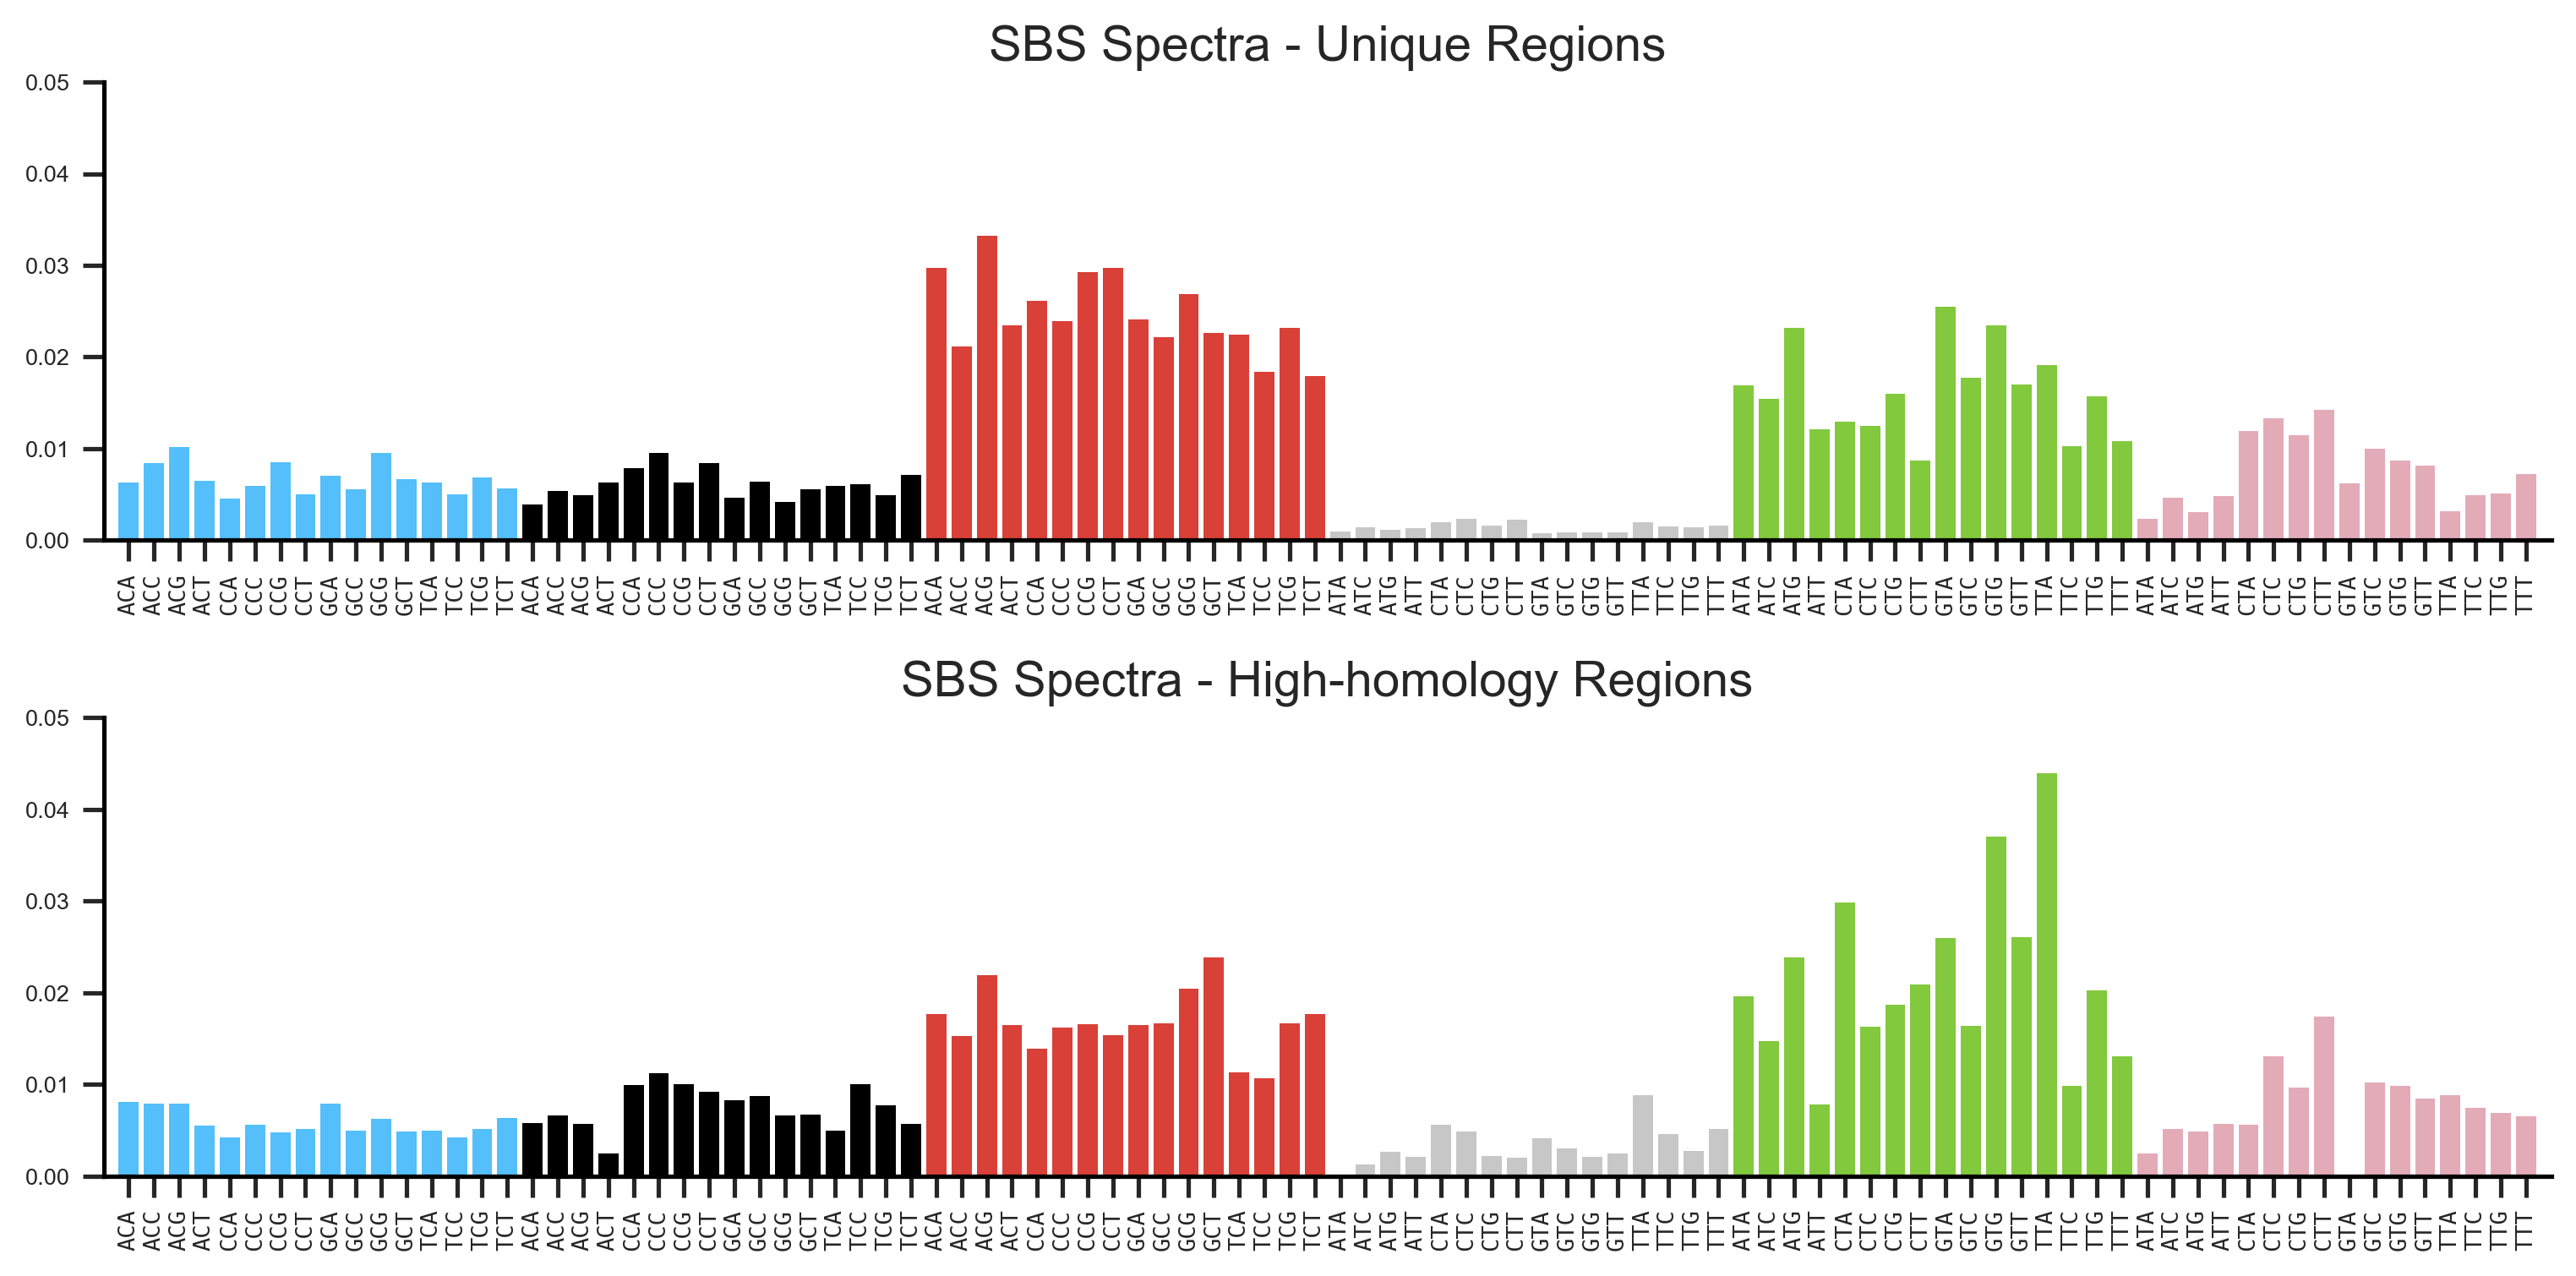

In [217]:
## Visualize mutational spectra in HHR and Unique Regions - Separately
fig = musical.sigplot_bar(MutSpec_DF[["Unq_L1Norm", "HHR_L1Norm"]],
                          ylim = (0, 0.05),
                          xticklabels = snv_types_96_TriNucRefs,
                          tick_fontsize = 6.5,
                          fix_size = True,
                          #tick_font="Open Sans",
                          title = ["SBS Spectra - Unique Regions", "SBS Spectra - High-homology Regions"],
                          )

### Visualize BACKGROUND triplet frequency of regions

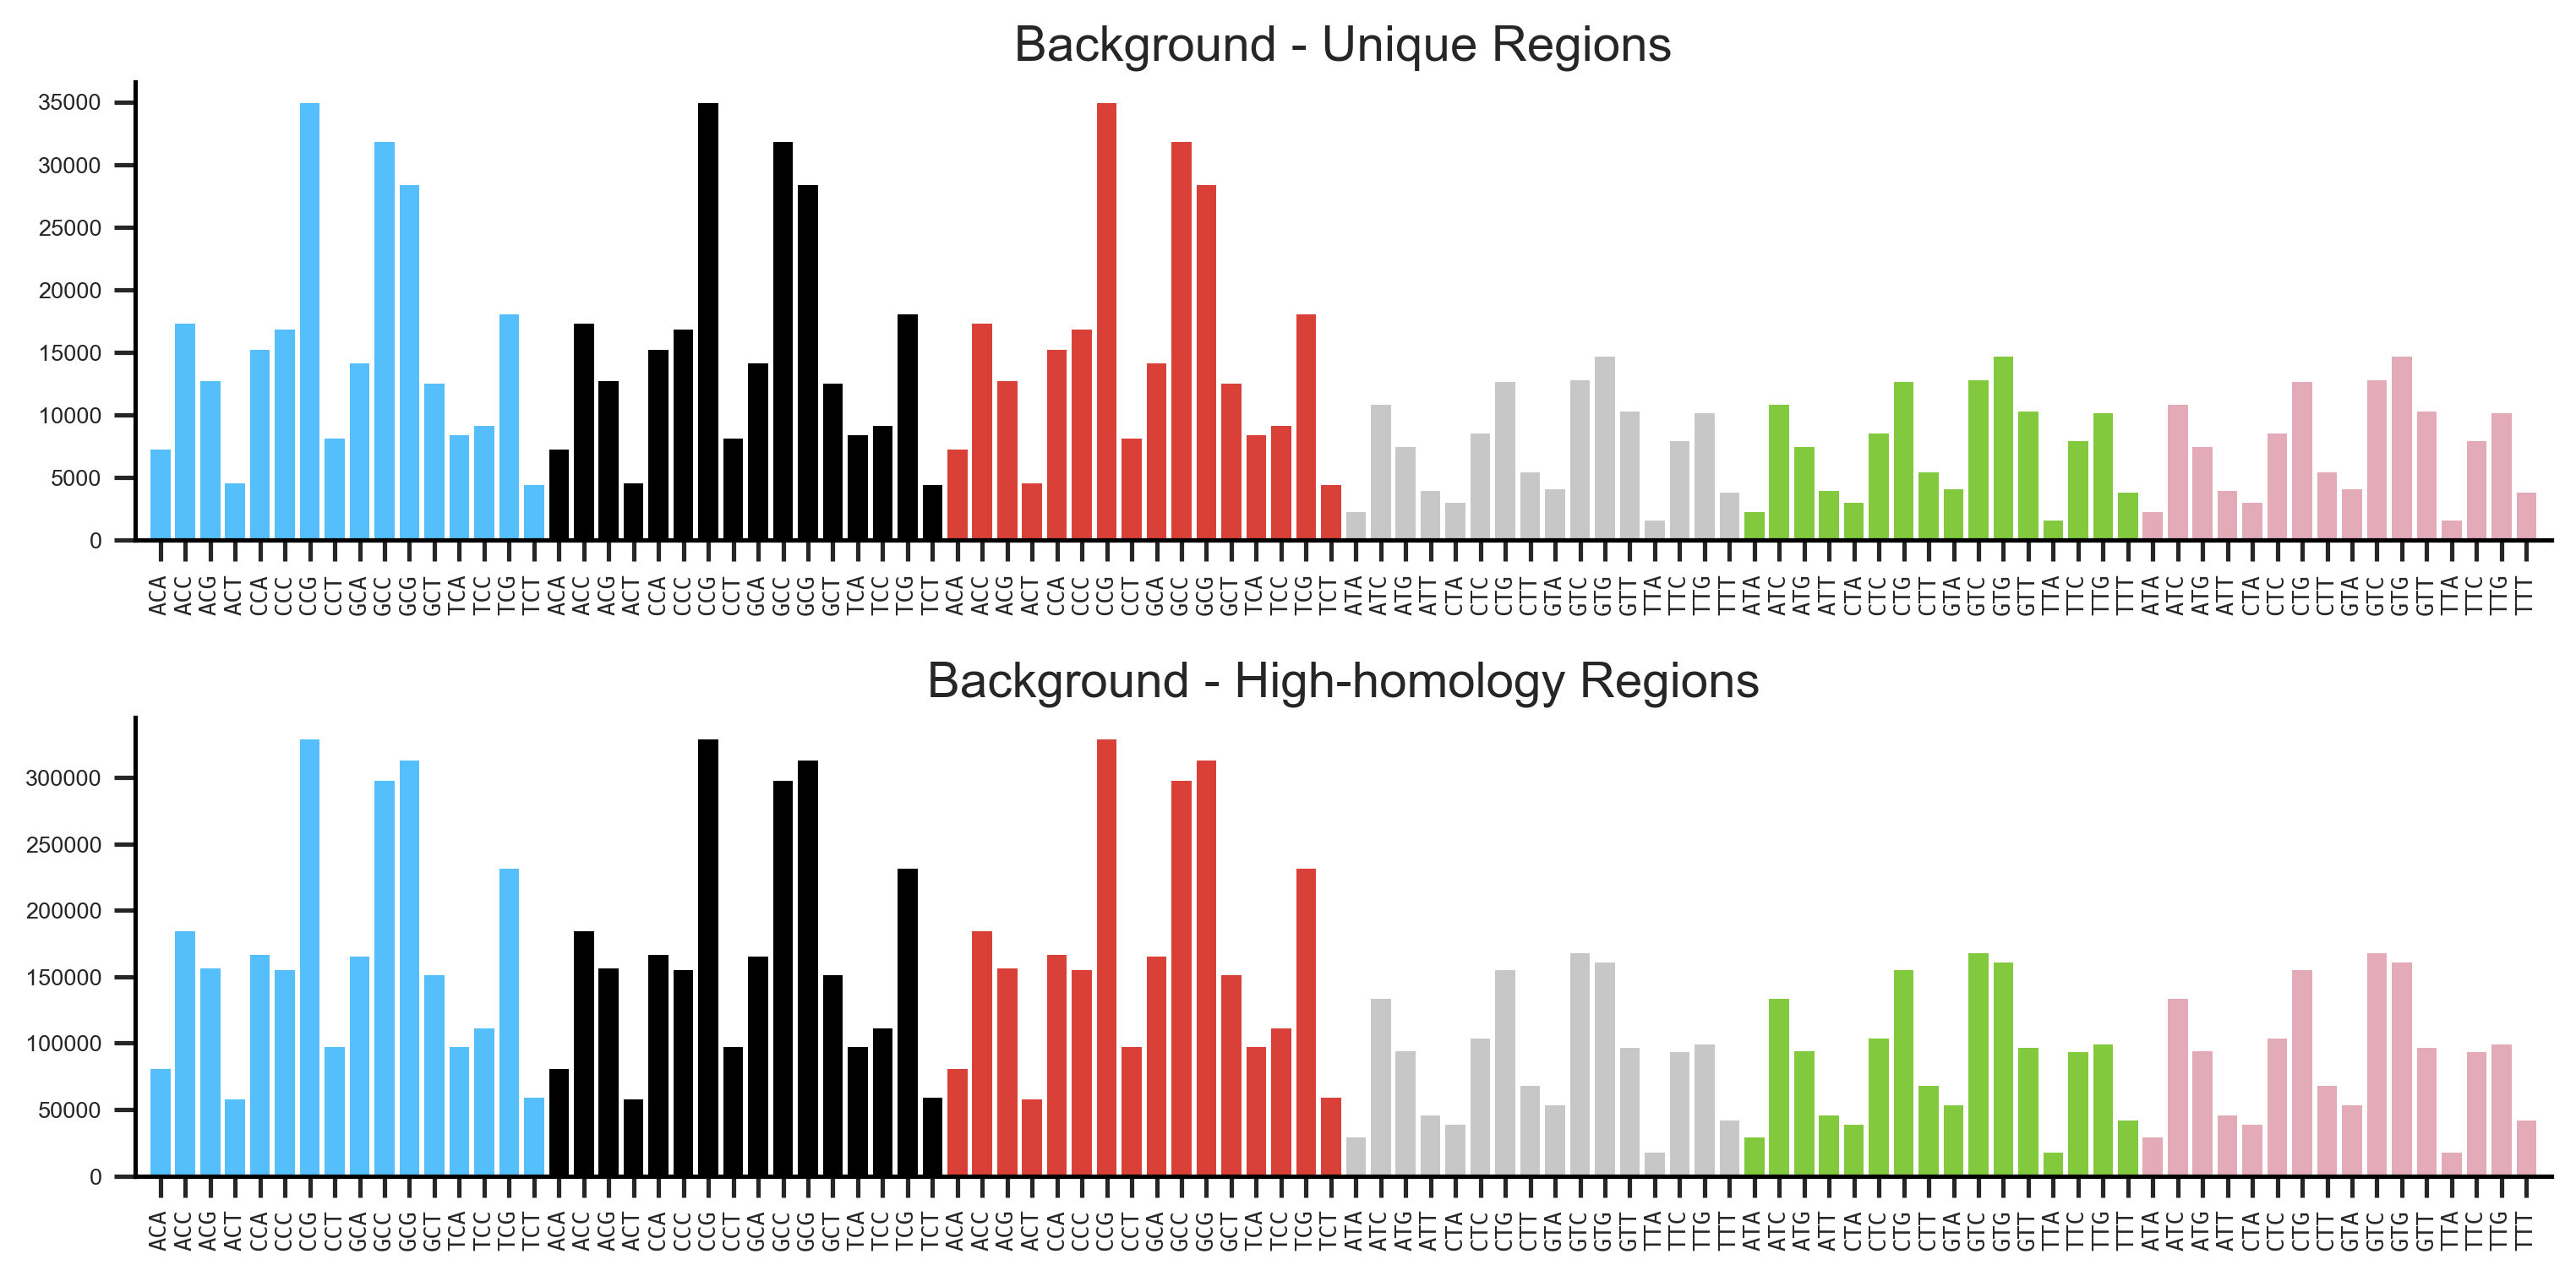

In [218]:
fig = musical.sigplot_bar(MutSpec_DF[["HHR_Background", "Unq_Background"]], norm = False,
                          title = ["Background - Unique Regions", "Background - High-homology Regions"],
                          xticklabels = snv_types_96_TriNucRefs,
                          tick_fontsize = 6.5,
                          fix_size = True,)

## Visualize mutational spectra in HHR, mGeneConv regions, and Unique Regions

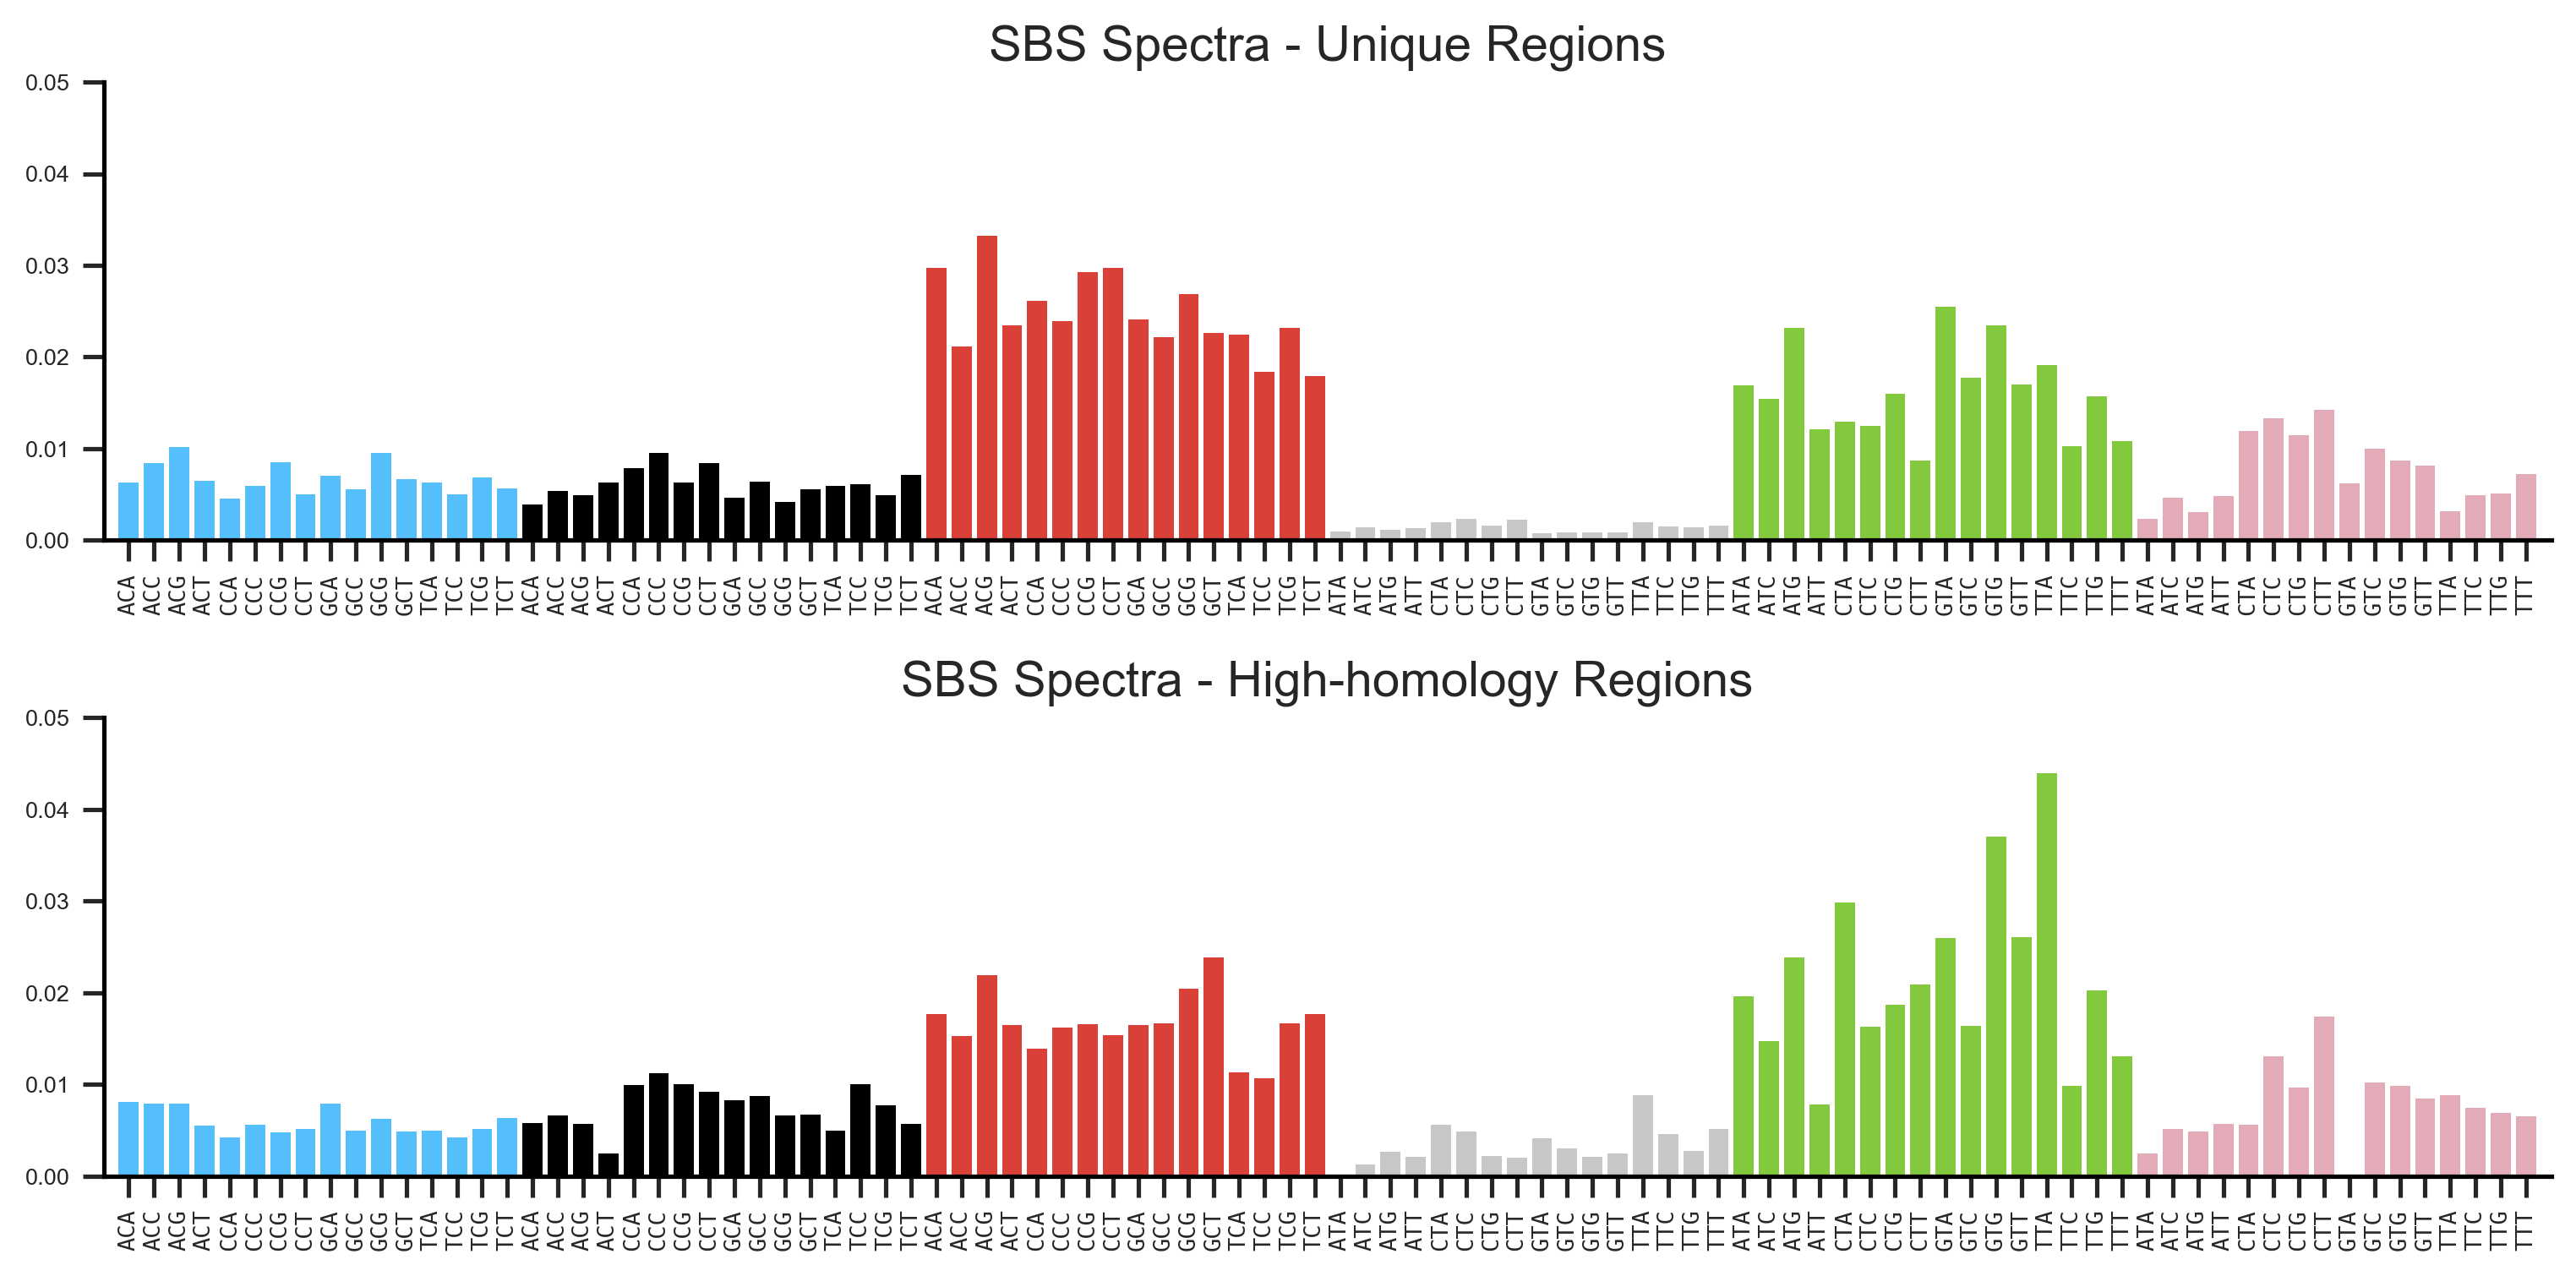

In [219]:
fig = musical.sigplot_bar(MutSpec_DF[["Unq_L1Norm", "HHR_L1Norm",]],
                          ylim = (0, 0.05),
                          title = ["SBS Spectra - Unique Regions",
                                   "SBS Spectra - High-homology Regions",],
                          xticklabels = snv_types_96_TriNucRefs,
                          tick_fontsize = 6.5,
                          fix_size = True, )

## Visualize DIFFERENCE in mutational spectra between HHR and Unique Regions

In [220]:
MutSpec_DF.sort_values("HHR_vs_Unq_Norm_Diff", ascending=False).head(1)

,SNV_nonsd,SNV_sd,SNV_sd_recomb,SNV_recomb,SNV_paralog,background_nonsd,background_sd,background_sd_recomb,background_recomb,background_nonsd.normalized,background_sd.normalized,background_sd_recomb.normalized,background_recomb.normalized,background_human.normalized,HHR_normalized,Unq_normalized,HHR_L1Norm,Unq_L1Norm,Type,GType,Ref3mer,L1Norm_Diff,HHR_vs_Unq_Norm_Diff,HHR_Background,Unq_Background,HHR_Background_normalized,Unq_Background_normalized,Background_Norm_Diff,CG_count,SNV_HHR,SNV_Unq,Background_HHR,Background_Unq
Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
T[T>C]A,48,25,24,20,289,17303,1584,680,129,0.001425,0.001455,0.001678,0.001867,0.013768,0.015783,0.002774,0.043902,0.019157,T[T>C]A,T>C,TTA,0.024745,0.024745,1584,17303,0.001455,0.001425,0.00003,0,25,48,1584,17303


In [221]:
MutSpec_DF["HHR_vs_Unq_Norm_Diff"].max()

0.024744896226648407

In [222]:
MutSpec_DF["HHR_vs_Unq_Norm_Diff"].min()

-0.014373193537095139

In [223]:
!mkdir ./MutAttributes_Plots/

mkdir: cannot create directory ‘./MutAttributes_Plots/’: File exists


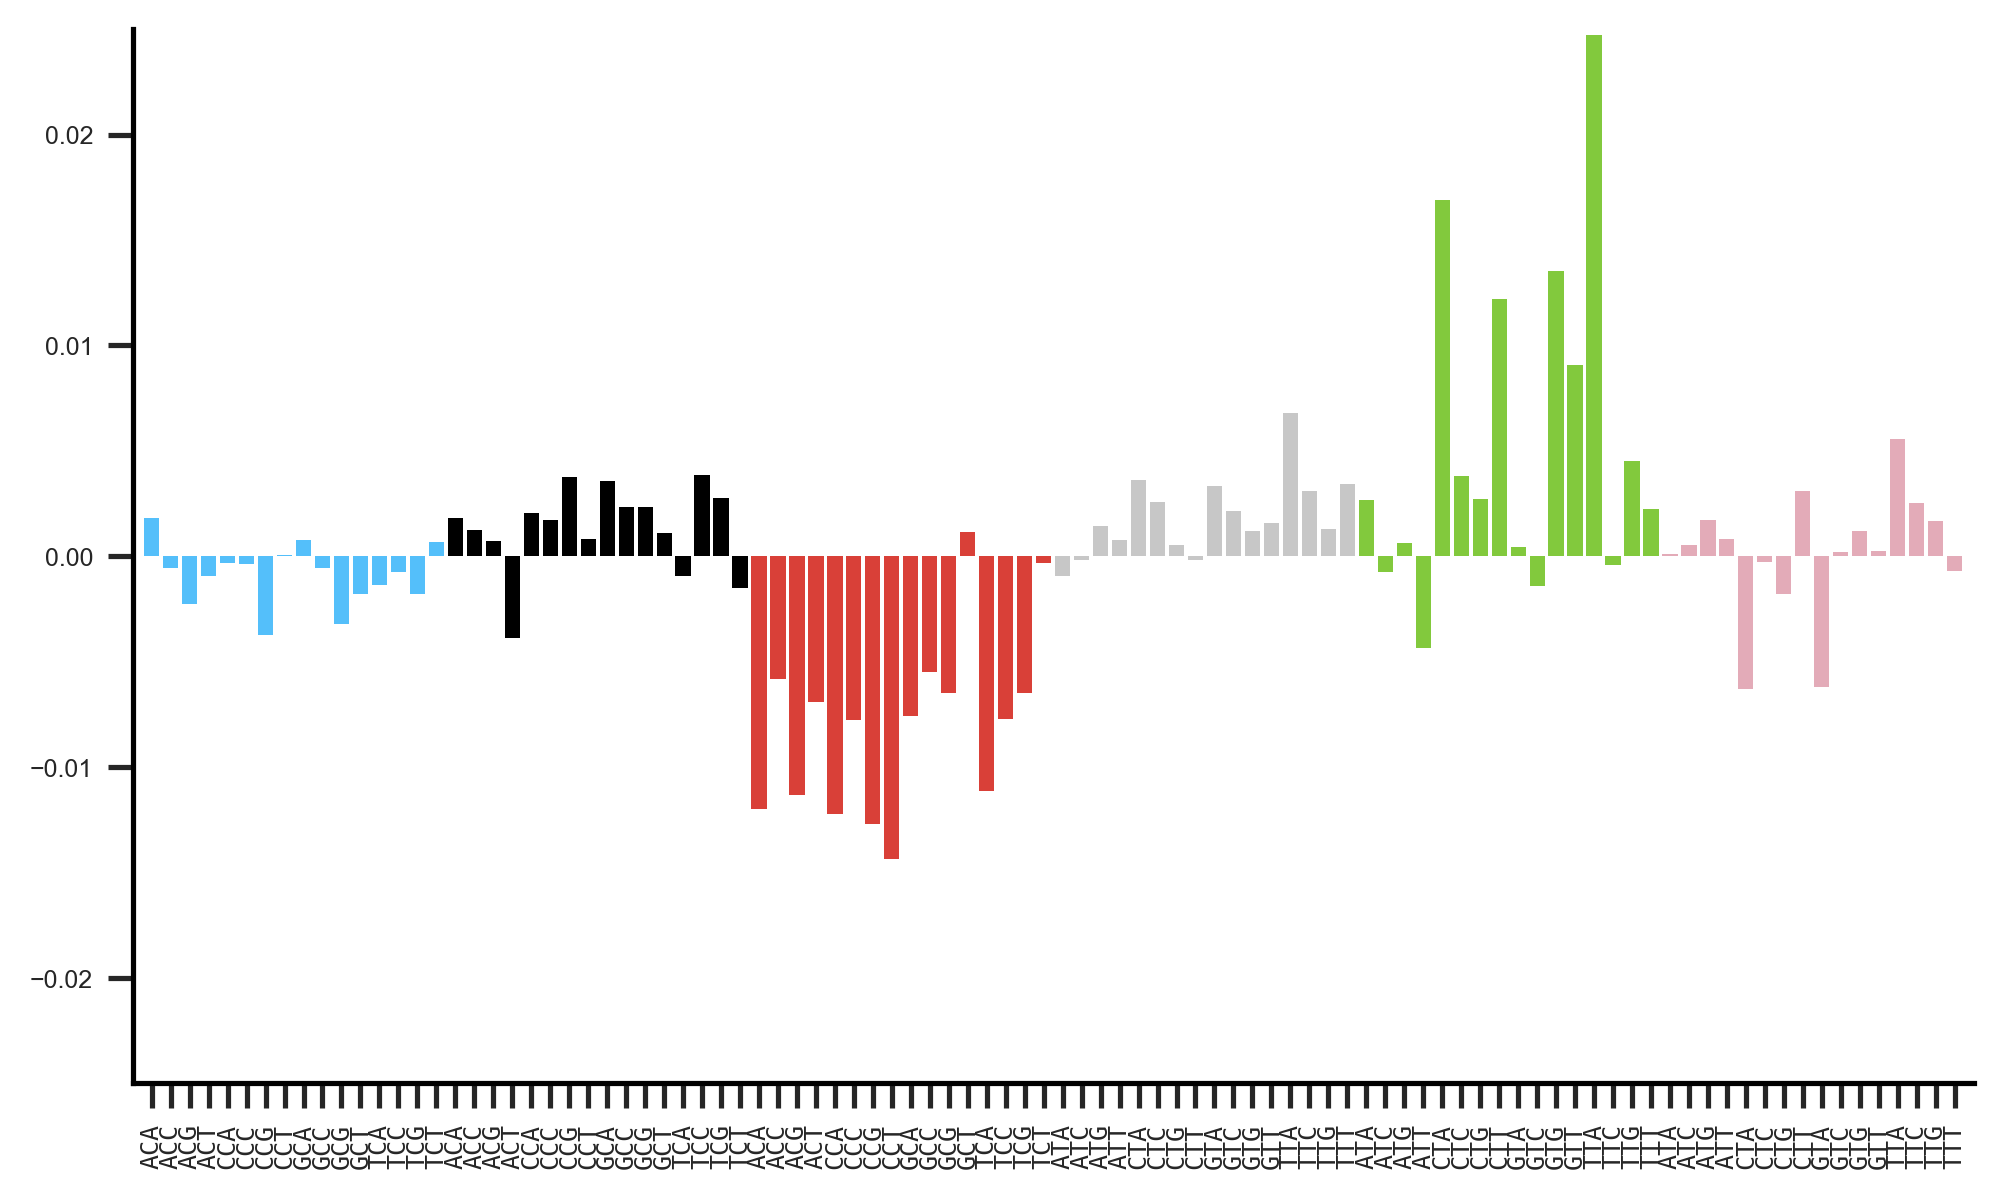

In [224]:

fig = musical.sigplot_bar(MutSpec_DF["HHR_vs_Unq_Norm_Diff"], norm=False,
                          ylim = (-.025, 0.025),
                          xticklabels = snv_types_96_TriNucRefs,
                          figsize = (5.3, 3.2),
                          tick_fontsize = 6,
                          fix_size = True,
                          title='')

#plt.savefig('MutAttributes_Plots/MutSig.HHRvsUnq.SBSFreqDifference.V1.pdf')
plt.savefig('MutAttributes_Plots/MutSig.HHRvsUnq.SBSFreqDifference.V1.svg')


## Visualize DIFFERENCE in background trinucleotide frequency

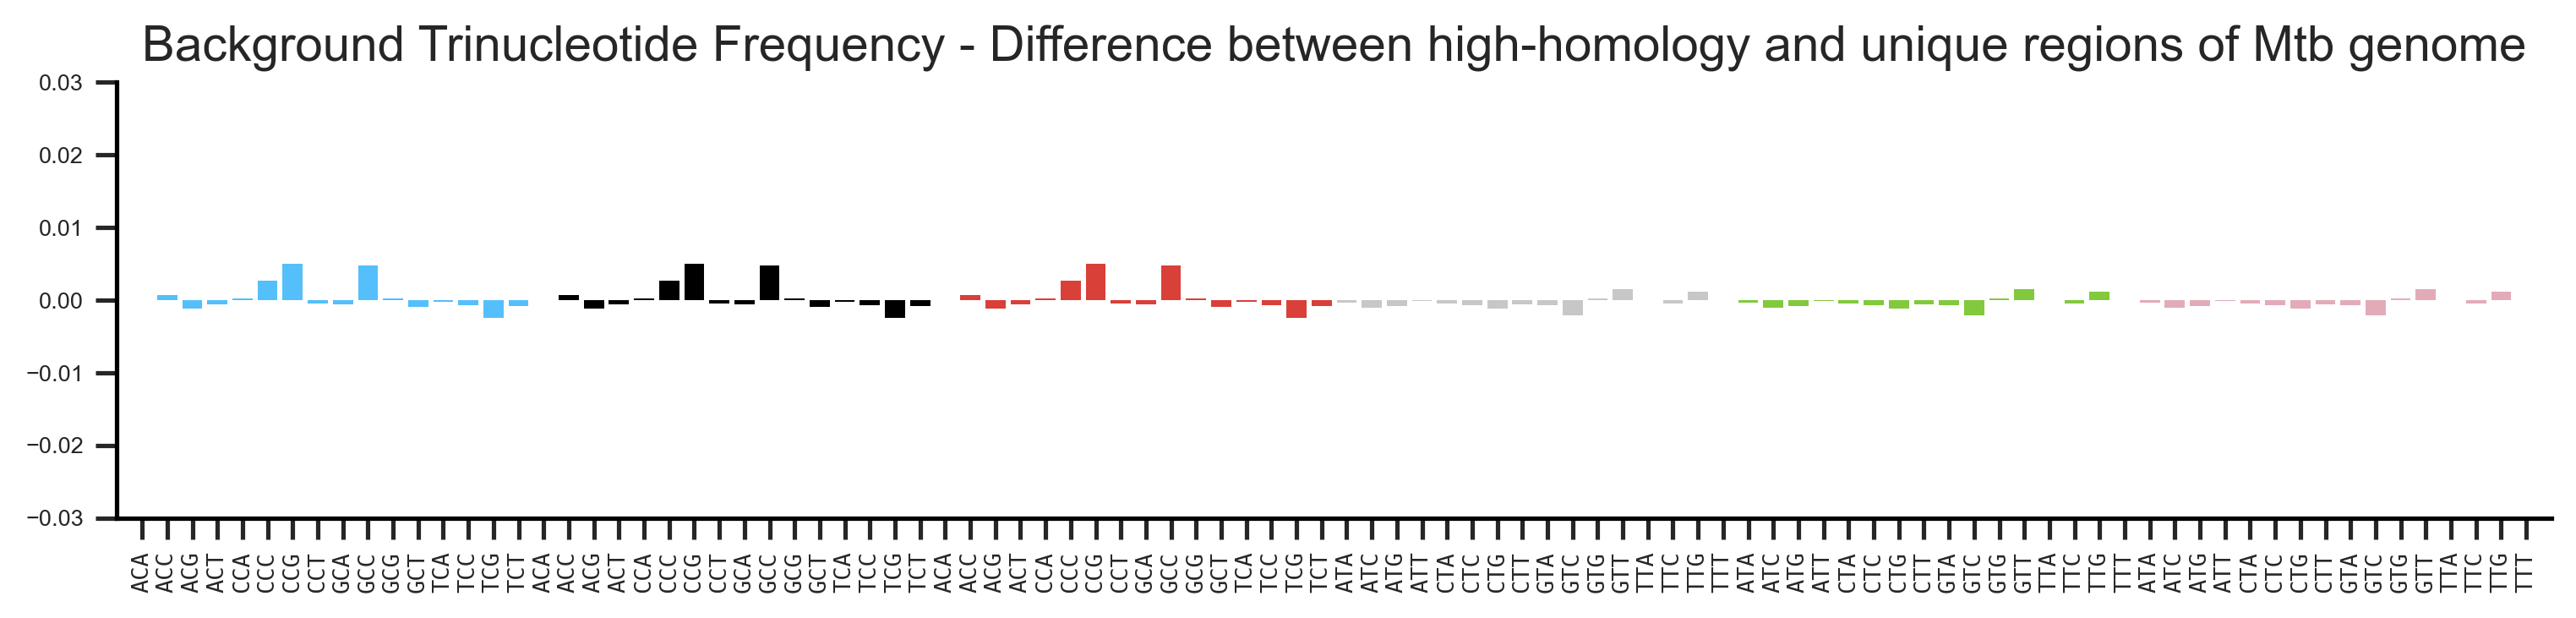

In [225]:


fig = musical.sigplot_bar(MutSpec_DF["Background_Norm_Diff"], norm=False,
                          ylim = (-.03, 0.03),
                          xticklabels = snv_types_96_TriNucRefs,
                          tick_fontsize = 6.5,
                          fix_size = True,
                          title='Background Trinucleotide Frequency - Difference between high-homology and unique regions of Mtb genome')

## Compare shifts in SBS type frequencies between HHR and Unique Regions

In [226]:
plt.style.use('../mgm.v1.mplstyle')

# Viz diff in SBS type between HHR and UNQ regions

In [227]:
MS_L1_Tidy.head(5)

,Type,GType,Category,normalized_frequency,RegionCategory
0,A[C>A]A,C>A,HHR_L1Norm,0.008086,HHR
1,A[C>A]C,C>A,HHR_L1Norm,0.007892,HHR
2,A[C>A]G,C>A,HHR_L1Norm,0.007874,HHR
3,A[C>A]T,C>A,HHR_L1Norm,0.005501,HHR
4,C[C>A]A,C>A,HHR_L1Norm,0.004209,HHR


In [228]:
MS_L1_Tidy["RegionCategory"].value_counts()

RegionCategory
HHR    96
Unq    96
Name: count, dtype: int64

In [229]:
MS_L1_Tidy.head(5)

,Type,GType,Category,normalized_frequency,RegionCategory
0,A[C>A]A,C>A,HHR_L1Norm,0.008086,HHR
1,A[C>A]C,C>A,HHR_L1Norm,0.007892,HHR
2,A[C>A]G,C>A,HHR_L1Norm,0.007874,HHR
3,A[C>A]T,C>A,HHR_L1Norm,0.005501,HHR
4,C[C>A]A,C>A,HHR_L1Norm,0.004209,HHR


In [230]:
plt.style.use('../mgm.v1.mplstyle')

In [231]:
# Define custom colors for "HHR" and "Unique" regions
HHRvsUnq_palette = {"HHR": "blue", "Unq": "grey"}


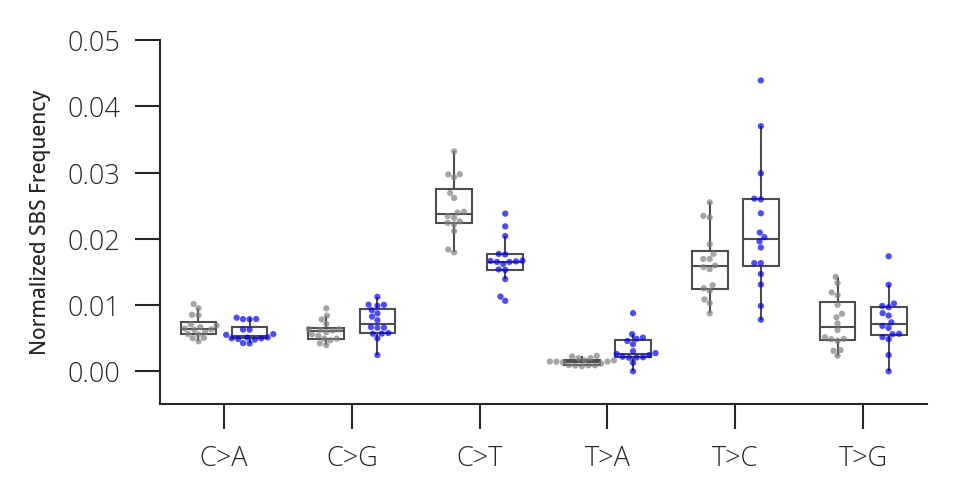

In [232]:
# Plot the normalized data for comparison
plt.figure(figsize=(3.2, 1.65))

sns.boxplot(data = MS_L1_Tidy, x="GType", y="normalized_frequency",
            hue="RegionCategory", palette = HHRvsUnq_palette,
            hue_order = ["Unq", "HHR"],
            linewidth = 0.5, #dodge = True,
            gap = .3,
            showcaps = False,
            boxprops=dict(facecolor="white",),  # Make fill white, with black edges

            # boxprops=dict(facecolor="white", edgecolor="black"),  # Make fill white, with black edges
            # medianprops=dict(color="black"), 
            legend=False, fliersize=0)

sns.swarmplot(data = MS_L1_Tidy, x="GType", y="normalized_frequency",
              hue="RegionCategory",
              hue_order = ["Unq", "HHR"],
              palette = HHRvsUnq_palette,
              s = 1.5, alpha = 0.7, dodge = True,
              #width = 1,
             legend=False)

# Customize the plot
plt.ylabel("Normalized SBS Frequency", fontsize=5)
plt.xlabel("")
plt.ylim(-0.005, 0.05)
plt.tight_layout()
sns.despine()

#plt.savefig('MutAttributes_Plots/MutSig.HHRvsUnq.SBSFreqComparison.BoxPlot.V1.pdf')
plt.savefig('MutAttributes_Plots/MutSig.HHRvsUnq.SBSFreqComparison.BoxPlot.V1.svg')

plt.show()


### Inspection of shifting SBS frequencies (HHR vs Unique)

In [233]:
MutSpec_SimpCol = ["GType", "Type", "Ref3mer", "L1Norm_Diff", "HHR_L1Norm", "Unq_L1Norm", "CG_count"]

MutSpec_DF.query("L1Norm_Diff > 0.005").sort_values("L1Norm_Diff", ascending = False)[MutSpec_SimpCol]

,GType,Type,Ref3mer,L1Norm_Diff,HHR_L1Norm,Unq_L1Norm,CG_count
Type,,,,,,,
T[T>C]A,T>C,T[T>C]A,TTA,0.024745,0.043902,0.019157,0
C[T>C]A,T>C,C[T>C]A,CTA,0.016898,0.029880,0.012982,1
G[T>C]G,T>C,G[T>C]G,GTG,0.013553,0.037002,0.023449,2
C[T>C]T,T>C,C[T>C]T,CTT,0.012185,0.020930,0.008745,1
G[T>C]T,T>C,G[T>C]T,GTT,0.009092,0.026052,0.016960,1
T[T>A]A,T>A,T[T>A]A,TTA,0.006785,0.008780,0.001995,0
T[T>G]A,T>G,T[T>G]A,TTA,0.005588,0.008780,0.003193,0


In [234]:
MutSpec_DF.query("L1Norm_Diff < -0.005").sort_values("L1Norm_Diff", ascending = True)[MutSpec_SimpCol]

,GType,Type,Ref3mer,L1Norm_Diff,HHR_L1Norm,Unq_L1Norm,CG_count
Type,,,,,,,
C[C>T]T,C>T,C[C>T]T,CCT,-0.014373,0.015374,0.029747,2
C[C>T]G,C>T,C[C>T]G,CCG,-0.012685,0.016590,0.029275,3
C[C>T]A,C>T,C[C>T]A,CCA,-0.012245,0.013908,0.026153,2
A[C>T]A,C>T,A[C>T]A,ACA,-0.012001,0.017712,0.029713,1
A[C>T]G,C>T,A[C>T]G,ACG,-0.011312,0.021873,0.033185,2
T[C>T]A,C>T,T[C>T]A,TCA,-0.011129,0.011286,0.022415,1
C[C>T]C,C>T,C[C>T]C,CCC,-0.007755,0.016198,0.023954,3
T[C>T]C,C>T,T[C>T]C,TCC,-0.007736,0.010635,0.018371,2
G[C>T]A,C>T,G[C>T]A,GCA,-0.007567,0.016506,0.024072,2


## Statistical testing for systematic shifts in SBS types

In [235]:
from scipy.stats import mannwhitneyu

In [236]:

NonSD_TC_Freq = MS_L1_Tidy.query("Category == 'HHR_L1Norm' & GType == 'T>C' ")["normalized_frequency"].values
SD_TC_Freq = MS_L1_Tidy.query("Category == 'Unq_L1Norm' & GType == 'T>C' ")["normalized_frequency"].values

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test) between the two arrays
stat, p_value = mannwhitneyu(NonSD_TC_Freq, SD_TC_Freq, alternative='two-sided', method = 'auto')

# Print the results
print("Statistic:", stat)
print("P-Value:", p_value)


Statistic: 177.0
P-Value: 0.06756268076355927


In [237]:

NonSD_TC_Freq = MS_L1_Tidy.query("Category == 'HHR_L1Norm' & GType == 'C>T' ")["normalized_frequency"].values
SD_TC_Freq = MS_L1_Tidy.query("Category == 'Unq_L1Norm' & GType == 'C>T' ")["normalized_frequency"].values

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test) between the two arrays
stat, p_value = mannwhitneyu(NonSD_TC_Freq, SD_TC_Freq, alternative='two-sided', method = 'auto')

# Print the results
print("Statistic:", stat)
print("P-Value:", p_value)


Statistic: 13.0
P-Value: 1.5932777797286954e-05


# Part 2: Distance between SNPs - Unique vs HHR Regions

In [238]:
PRvsUnq_palette = {"PR": "blue", "Unq": "grey"}


In [239]:
WGA151_SNPs_InterSNPDists_DF.head(3)

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,DistToNearestSNP,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,RegionType,NucDivHotspot_Ovrlap,LogDist
0,01_R1134,NC_000962.3,1976,1977,A,G,True,2035,0,0,Unq,False,3.308564
1,01_R1134,NC_000962.3,4012,4013,T,C,True,2035,0,0,Unq,False,3.308564
2,01_R1134,NC_000962.3,7361,7362,G,C,True,222,0,0,Unq,False,2.346353


### Compare SNP-dist distributions (HHR vs UNQ) (p < 0.0001, mannwhitneyu test)

In [240]:
WGA151_SNPs_InterSNPDists_DF.groupby("RegionType").describe()["DistToNearestSNP"]

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
RegionType,,,,,,,,
PR,49938.0,350.841083,1024.211561,0.0,1.0,8.0,207.0,32229.0
Unq,170492.0,1736.012787,2130.708734,0.0,383.0,1016.0,2312.0,57196.0


In [241]:
WGA151_SNPs_InterSNPDists_DF["RegionType"].value_counts()

RegionType
Unq    170492
PR      49938
Name: count, dtype: int64

In [242]:
from scipy.stats import mannwhitneyu

PR_SNPs_DF = WGA151_SNPs_InterSNPDists_DF.query("RegionType == 'PR'")
Unq_SNPs_DF = WGA151_SNPs_InterSNPDists_DF.query("RegionType == 'Unq'")

# Conducting the Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(PR_SNPs_DF["DistToNearestSNP"],
                                    Unq_SNPs_DF["DistToNearestSNP"],
                                    alternative='two-sided')

u_statistic, p_value

(1168076460.5, 0.0)

## Viz inter-SNP distributions between HHR and Unique Regions

In [243]:
!mkdir MutAttributes_Plots/

mkdir: cannot create directory ‘MutAttributes_Plots/’: File exists


In [244]:
plt.style.use('../mgm.v1.mplstyle')

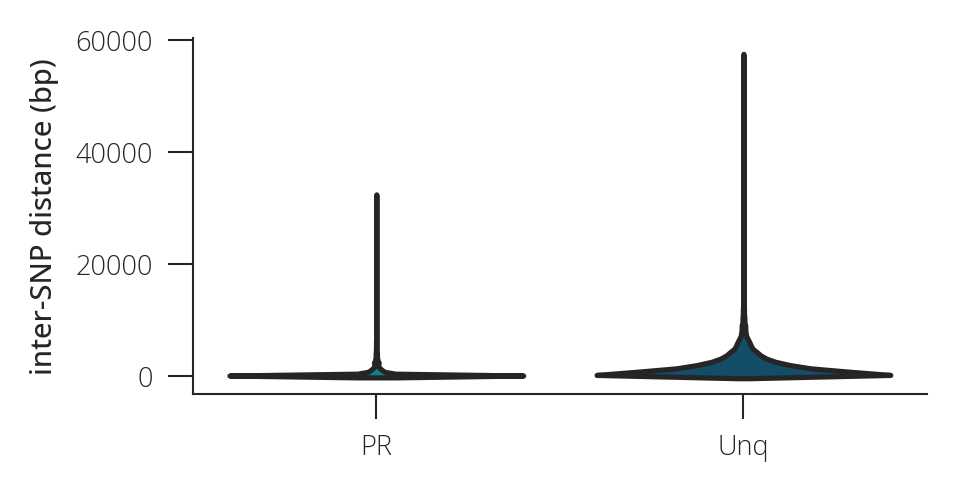

In [245]:
fig, ax1 = plt.subplots(1, 1,
                        figsize=(3.2, 1.65),
                        sharex=True)
sns.violinplot(y = "DistToNearestSNP",
             x = "RegionType",
             hue = "RegionType",
             data = WGA151_SNPs_InterSNPDists_DF, order = ["PR", "Unq"],
             ax = ax1,
               inner = None,
             legend=False,)

#ax1.set_ylim(-100, 6100)

ax1.set_xlabel("")
ax1.set_ylabel("inter-SNP distance (bp)")
sns.despine()

#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LinearY.V2.pdf')
#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LinearY.V2.svg')
plt.show()


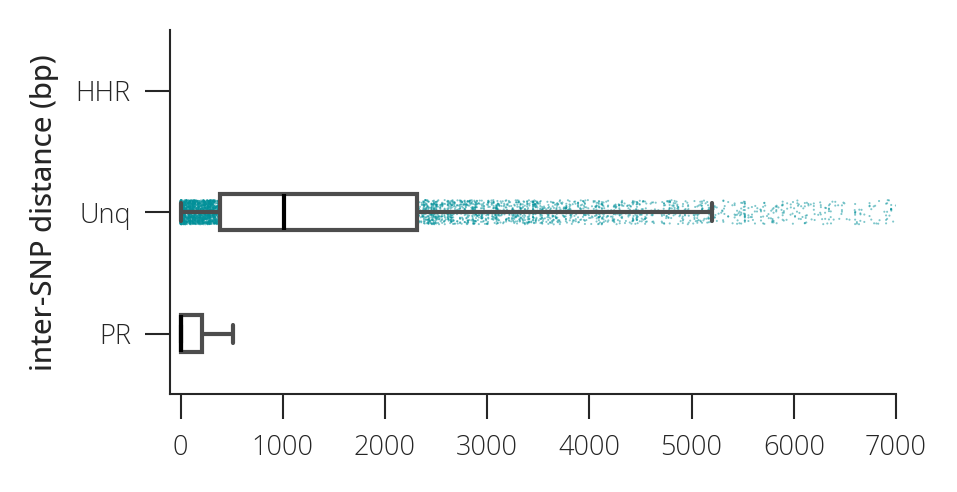

In [246]:
fig, ax1 = plt.subplots(1, 1,
                        figsize=(3.2, 1.65),
                        sharex=True)

np.random.seed(42)

sns.stripplot(x = "DistToNearestSNP",
               y = "RegionType",
               hue = "RegionType",
               data = WGA151_SNPs_InterSNPDists_DF.sample(10000),
               zorder= 0,
               order = ["HHR", "Unq"],
               s = 0.5, alpha = 0.5,
               ax = ax1,
               legend=False,)

sns.boxplot(x = "DistToNearestSNP",
             y = "RegionType",
             hue = "RegionType",
             data = WGA151_SNPs_InterSNPDists_DF, order = ["PR", "Unq"],
             palette = PRvsUnq_palette,
             ax = ax1, legend=False,
             width = 0.3, zorder= 1,
             boxprops=dict(facecolor="white"),  # Make fill white, with black edges
             medianprops=dict(color="black"), 
             showfliers=False)

ax1.set_xlim(-100, 7000)

ax1.set_xlabel("")
ax1.set_ylabel("inter-SNP distance (bp)")
sns.despine()

plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LinearX.V2.svg')
plt.show()


In [247]:
WGA151_SNPs_InterSNPDists_DF.groupby("RegionType").describe()["DistToNearestSNP"]

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
RegionType,,,,,,,,
PR,49938.0,350.841083,1024.211561,0.0,1.0,8.0,207.0,32229.0
Unq,170492.0,1736.012787,2130.708734,0.0,383.0,1016.0,2312.0,57196.0


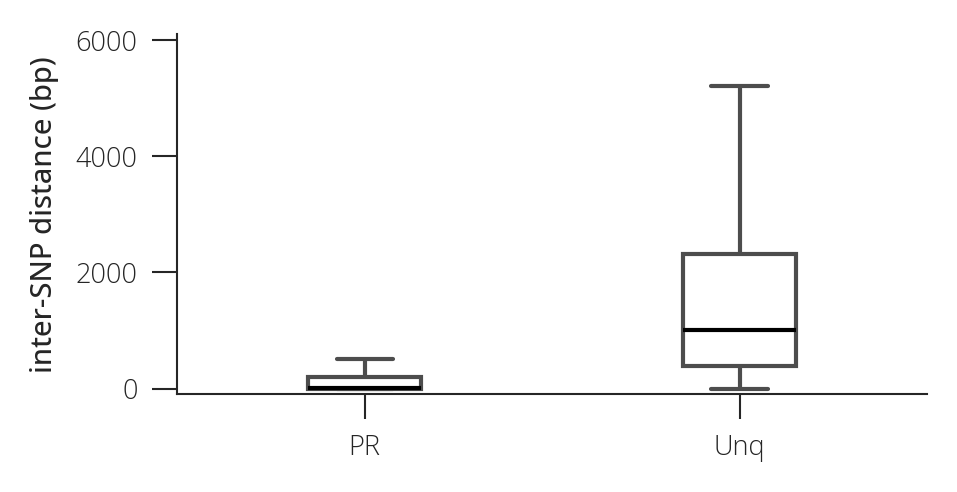

In [248]:
fig, ax1 = plt.subplots(1, 1,
                        figsize=(3.2, 1.65),
                        sharex=True)
sns.boxplot(y = "DistToNearestSNP",
             x = "RegionType",
             hue = "RegionType",
             data = WGA151_SNPs_InterSNPDists_DF, order = ["PR", "Unq"],
             palette=PRvsUnq_palette,
            ax = ax1, legend=False,
             width = 0.3,
             boxprops=dict(facecolor="white"),  # Make fill white, with black edges
             medianprops=dict(color="black"), 
             showfliers=False)

ax1.set_ylim(-100, 6100)

ax1.set_xlabel("")
ax1.set_ylabel("inter-SNP distance (bp)")
sns.despine()

#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LinearY.V2.pdf')
#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LinearY.V2.svg')
plt.show()


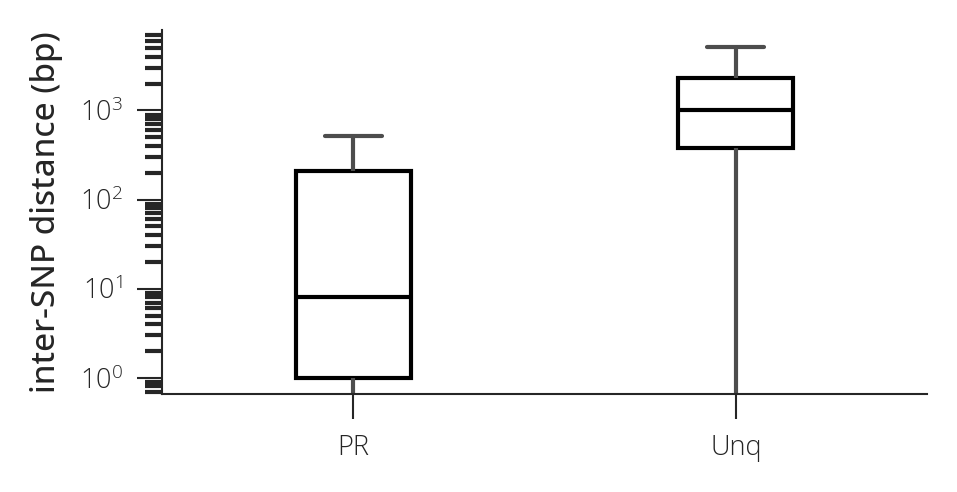

In [249]:
fig, ax1 = plt.subplots(1, 1,
                        figsize=(3.2, 1.65),
                        sharex=True)


sns.boxplot(y = "DistToNearestSNP",
             x = "RegionType",
             hue = "RegionType",
             data = WGA151_SNPs_InterSNPDists_DF, order = ["PR", "Unq"],
             palette=PRvsUnq_palette,
            ax = ax1, legend=False,
             width = 0.3,
             boxprops=dict(facecolor="white", edgecolor="black"),  # Make fill white, with black edges
             medianprops=dict(color="black"), 
             showfliers=False)

ax1.set_xlabel("")
ax1.set_ylabel("inter-SNP distance (bp)", fontsize=8)

ax1.set_yscale('log')

# # Create custom legend handles
# legend_handles = [
#     mpatches.Patch(color=HHRvsUnq_palette["HHR"], label="HHR (High Homology Region)"),
#     mpatches.Patch(color=HHRvsUnq_palette["Unq"], label="Unique Regions")
# ]

# Add legend to your plot
#fig.legend(handles=legend_handles, title="Region Type", loc="upper right", fontsize=7, title_fontsize=8)

sns.despine()
#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LogY.V2.pdf')
#plt.savefig('MutAttributes_Plots/SNPDistances.HHRvsUnq.Boxplot.LogY.V2.svg')

plt.show()


# Part 3: SNP Event overlap with PR sequence differences (Rv paralogs)

## Q1: How many Gubbins SNP events overlap w/ a paralogous region (PR)?

In [250]:
GubSNPs_CDSAnno_All_V2_DF.head(1)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,Lineage,EventID,Pos_0based,Chrom,Num_ParalogAln_Ovrlap,PR_HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut
0,1088,Node_1,N1176,G,A,lineage5,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True


In [251]:
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [252]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF.shape

(26508, 27)

### Preprocessing & annotated Gubbins ASR SNPs

In [253]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF.shape

(26508, 27)

In [254]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF["InEvent"].value_counts()

InEvent
1    26508
Name: count, dtype: int64

In [255]:
Gubbins_SNPs_AnnoByParalogSNPMatch_DF["HmVarMatch"].value_counts()

HmVarMatch
0    23680
1     2828
Name: count, dtype: int64

## Systematically test each HHR for an enrichment of mutations matching paralogs

### Run `for` loop to perform test for each unique HHR

In [256]:
from scipy import stats

In [257]:
Gub_SNPComp_CoordCols_V2 = ("Chrom", "Pos_0based", "Pos_1based")
Paf_SNPComp_CoordCols_V2 = ("Target_Name", "Target_Start", "Target_End")

listOfRows_SNPvsParalog = []

for i, row in tqdm(HmMapRegs_ParaRegs_k19w19_DF.iterrows()):
    i_HmRegionID = row["HmRegionID"]
    i_Overlap_Genes = row["Overlap_Genes"]
    i_Length = row["Length"]
    NPossible_SNPs = i_Length * 3

    # a) Target overlapping genes
    i_Start = int(row["Start"])
    i_End = int(row["End"])
    Target_Range = f"NC_000962.3:{i_Start}-{i_End}"
    
    Ovrlap_UnqSNPsInParalogs_DF = bf.select(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF, Target_Range, cols = Paf_SNPComp_CoordCols_V2)      

    NPossible_ParalogSNPs = Ovrlap_UnqSNPsInParalogs_DF.shape[0]

    
    Ovrlap_MutEvent_SNP_DF = bf.select(Gubbins_SNPs_AnnoByParalogSNPMatch_DF, Target_Range, cols = Gub_SNPComp_CoordCols_V2)     

    
    NObserved_SNPs_Total     = Ovrlap_MutEvent_SNP_DF.shape[0]
    NObserved_SNPs_MatchParalogSNP = Ovrlap_MutEvent_SNP_DF.query("HmVarMatch == 1").shape[0]


    # Perform the hypergeometric test
    p_value = stats.hypergeom.sf(NObserved_SNPs_MatchParalogSNP - 1,
                                 NPossible_SNPs,
                                 NPossible_ParalogSNPs,
                                 NObserved_SNPs_Total)

    # Perform the hypergeometric test in log-space
    log_p_value = stats.hypergeom.logsf(NObserved_SNPs_MatchParalogSNP - 1,
                                        NPossible_SNPs,
                                        NPossible_ParalogSNPs,
                                        NObserved_SNPs_Total)
        
    # Calculate the expected number of paralog matches under random chance
    expected_paralog_matches = NObserved_SNPs_Total * (NPossible_ParalogSNPs / NPossible_SNPs)

    if NObserved_SNPs_Total > 0:
        row["NPossible_SNPs_Total"] = NPossible_SNPs
        row["NPossible_ParalogSNPs"] = NPossible_ParalogSNPs
        
        row["NObserved_SNPs_Total"] = NObserved_SNPs_Total
        row["NObserved_SNPs_MatchParalogSNP"] = NObserved_SNPs_MatchParalogSNP
        row["p_value"] = p_value
        row["log_p_value"] = log_p_value
        row["neglog_p_value"] = -log_p_value

        row["NExpected_MatchParalogSNP"] = expected_paralog_matches

        listOfRows_SNPvsParalog.append(row)

HHR_SNP_DF = pd.DataFrame(listOfRows_SNPvsParalog)

HHR_SNP_DF["p_corr"] = (HHR_SNP_DF["p_value"] * HHR_SNP_DF.shape[0]).clip(lower = 1e-40, upper = 1)

HHR_SNP_DF["neglog_p_corr"] =  (HHR_SNP_DF["neglog_p_value"]) - np.log( HHR_SNP_DF.shape[0] )
HHR_SNP_DF["neglog_p_corr"] = HHR_SNP_DF["neglog_p_corr"].clip(lower=0)

HHR_SNP_DF = bf.count_overlaps(HHR_SNP_DF,
                               NucDiv_HSR_1kb_DF,
                               cols1 = ("Chr", "Start", "End"),
                               cols2 = ("Chrom", "Start", "End") )

HHR_SNP_DF.rename(columns={'count': 'NucDivHotspot_Ovrlap'}, inplace=True)
HHR_SNP_DF.replace([np.inf, -np.inf], 500, inplace=True)

HHR_SNP_DF["FoldEnrichment"] =  HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] /  HHR_SNP_DF["NExpected_MatchParalogSNP"] 
HHR_SNP_DF["LogFoldEnrichment"] =  np.log10( HHR_SNP_DF["FoldEnrichment"] ).replace([np.inf, -np.inf], 0).fillna(0)
HHR_SNP_DF["Log2FoldEnrichment"] =  np.log2( HHR_SNP_DF["FoldEnrichment"] ).replace([np.inf, -np.inf], 0).fillna(0)
HHR_SNP_DF["AbsEnrichment"] = HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] - HHR_SNP_DF["NExpected_MatchParalogSNP"]
HHR_SNP_DF["SizeFactor"] = HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] / HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"].max()

#HHR_SNP_10ME_DF = HHR_SNP_DF.query("NObserved_SNPs_Total >= 10")

# Compute the natural log of 0.01
p_corr_LogThresh_01 = -np.log(0.01)


HHR_SNP_DF["Fraction_SNPs_MatchParalog"] = HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] / HHR_SNP_DF["NObserved_SNPs_Total"]

HHR_SNP_Sig_DF = HHR_SNP_DF.query(f"neglog_p_corr > {p_corr_LogThresh_01}").sort_values(["Log2FoldEnrichment", "neglog_p_corr", "NObserved_SNPs_MatchParalogSNP"], ascending=False)


HHR_SNP_NotSig_DF = HHR_SNP_DF.query(f"neglog_p_corr <= {p_corr_LogThresh_01}").sort_values(["neglog_p_corr", "Log2FoldEnrichment", "NObserved_SNPs_MatchParalogSNP"], ascending=False)

HHR_SNP_Sig_DHS_DF = HHR_SNP_Sig_DF.query("NucDivHotspot_Ovrlap > 0")


HHR_SNP_Sig_DF.shape

200it [00:01, 110.62it/s]
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


(60, 32)

In [258]:
HHR_SNP_Sig_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
128,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,PR_Set_24,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,0.235294
20,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,PR_Set_13,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,0.300000


In [259]:
HHR_SNP_Sig_DF.head(3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
128,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,PR_Set_24,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,0.235294
20,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,PR_Set_13,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,0.300000
38,44,NC_000962.3,1169296,1170733,1170014.5,1437,Rv1047,1,5,3,0,44,PR_HmRegion_044,0,PR_Set_30,4311,2,34,16,0.0,500.0,500.0,0.015774,1.000000e-40,500.0,0,1014.352941,3.006189,9.986344,15.984226,0.074419,0.470588


In [260]:
-np.log(1)

-0.0

### Output TSV of HHRs tested for ParalogMatching SNPs

In [261]:
!pwd

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_ParalogRegions_MutPatternComparison_V4


In [262]:
!mkdir ./EnrichTestForParalogSNPs_PerParalogRegion/

In [263]:
HHR_SNP_DF.to_csv("./EnrichTestForParalogSNPs_PerParalogRegion/PRs.TestedForParalogSNPS.AllRegions.V1.tsv", sep = "\t", index=False)

In [264]:
HHR_SNP_Sig_DF.to_csv("./EnrichTestForParalogSNPs_PerParalogRegion/PRs.TestedForParalogSNPS.SigOnly.V1.tsv", sep = "\t", index=False)

In [265]:
#!head ./HHR.TestedForParalogSNPS.V1.tsv

### OVERALL, How many total SNPs occured in HHRs? How many match a paralog exactly? (2756/4698, 59%)

In [266]:
HHR_SNP_Sig_DF["NObserved_SNPs_Total"].sum()

4694

In [267]:
HHR_SNP_Sig_DF["NObserved_SNPs_MatchParalogSNP"].sum()

2745

In [139]:
2756/4698

0.5866326096211154

#### Look at top HHRs ranked by Number of SNPs matching a paralog

In [140]:
HHRTarCols = ["Overlap_Genes", "HmRegion_Num", "NPossible_SNPs_Total", "NPossible_ParalogSNPs", "NObserved_SNPs_Total", "NObserved_SNPs_MatchParalogSNP", "p_value",
              "Log2FoldEnrichment", "neglog_p_corr", "AbsEnrichment",
              #"NObserved_SNPs_Total", "NObserved_SNPs_MatchParalogSNP",
              "NucDivHotspot_Ovrlap"]

HHR_SNP_Sig_DF.sort_values("NObserved_SNPs_MatchParalogSNP", ascending=False).head(12)[HHRTarCols]

,Overlap_Genes,HmRegion_Num,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,Log2FoldEnrichment,neglog_p_corr,AbsEnrichment,NucDivHotspot_Ovrlap
0,"Rv0094c,Rv0095c",2,4275,35,417,215,0.000000e+00,5.976715,500.000000,211.585965,3
75,"Rv1944c,Rv1945",94,4512,62,227,205,0.000000e+00,6.038287,500.000000,201.880762,1
139,"Rv3466,Rv3467",180,4158,35,282,193,0.000000e+00,6.345297,500.000000,190.626263,1
44,Rv1148c,50,4515,62,188,155,0.000000e+00,5.907850,500.000000,152.418383,1
140,"PE31,PPE60",182,4716,210,175,153,1.048992e-212,4.295279,483.043964,145.207379,1
57,"PE_PGRS28,Rv1453",65,8568,424,249,131,2.129738e-109,3.410243,245.169530,118.677871,2
56,PE_PGRS27,64,4440,184,255,125,5.072751e-123,3.564213,276.537837,114.432432,1
35,"Rv0979c,rpmF,PE_PGRS18",41,5595,74,122,91,0.000000e+00,5.817526,500.000000,89.386416,2
132,PPE55,171,28407,3288,167,90,1.326238e-40,2.219113,86.764811,70.670398,2
48,"PPE18,esxK,esxL",54,2394,53,128,87,0.000000e+00,4.940230,500.000000,84.166249,2


In [141]:
HHR_SNP_Sig_DF.sort_values("NObserved_SNPs_MatchParalogSNP", ascending=False).head(12)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
0,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,4275,35,417,215,0.000000e+00,500.000000,500.000000,3.414035,1.000000e-40,500.000000,3,62.975334,1.799170,5.976715,211.585965,1.000000,0.515588
75,94,NC_000962.3,2195856,2197360,2196608.0,1504,"Rv1944c,Rv1945",0,1,1,1,94,PR_HmRegion_094,0,PR_Set_34,4512,62,227,205,0.000000e+00,500.000000,500.000000,3.119238,1.000000e-40,500.000000,1,65.721188,1.817705,6.038287,201.880762,0.953488,0.903084
139,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,4158,35,282,193,0.000000e+00,500.000000,500.000000,2.373737,1.000000e-40,500.000000,1,81.306383,1.910125,6.345297,190.626263,0.897674,0.684397
44,50,NC_000962.3,1276292,1277797,1277044.5,1505,Rv1148c,0,1,1,1,50,PR_HmRegion_050,0,PR_Set_34,4515,62,188,155,0.000000e+00,500.000000,500.000000,2.581617,1.000000e-40,500.000000,1,60.039894,1.778440,5.907850,152.418383,0.720930,0.824468
140,182,NC_000962.3,3894016,3895588,3894802.0,1572,"PE31,PPE60",0,2,2,2,182,PR_HmRegion_182,0,PR_Set_36,4716,210,175,153,1.048992e-212,-488.100210,488.100210,7.792621,1.000000e-40,483.043964,1,19.633959,1.293008,4.295279,145.207379,0.711628,0.874286
57,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,8568,424,249,131,2.129738e-109,-250.225776,250.225776,12.322129,1.000000e-40,245.169530,2,10.631280,1.026586,3.410243,118.677871,0.609302,0.526104
56,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,4440,184,255,125,5.072751e-123,-281.594083,281.594083,10.567568,1.000000e-40,276.537837,1,11.828645,1.072935,3.564213,114.432432,0.581395,0.490196
35,41,NC_000962.3,1094827,1096692,1095759.5,1865,"Rv0979c,rpmF,PE_PGRS18",0,2,2,2,41,PR_HmRegion_041,0,PR_Set_27,5595,74,122,91,0.000000e+00,500.000000,500.000000,1.613584,1.000000e-40,500.000000,2,56.396212,1.751250,5.817526,89.386416,0.423256,0.745902
132,171,NC_000962.3,3743709,3753178,3748443.5,9469,PPE55,0,16,16,16,171,PR_HmRegion_171,0,PR_Set_24,28407,3288,167,90,1.326238e-40,-91.821057,91.821057,19.329602,2.082194e-38,86.764811,2,4.656071,0.668020,2.219113,70.670398,0.418605,0.538922
48,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28,2394,53,128,87,0.000000e+00,500.000000,500.000000,2.833751,1.000000e-40,500.000000,2,30.701356,1.487158,4.940230,84.166249,0.404651,0.679688


In [142]:
HHR_SNP_Sig_DF.sort_values("NObserved_SNPs_MatchParalogSNP", ascending=False).head(12)["HmRegion_Num"].values

array([  2,  94, 180,  50, 182,  65,  64,  41, 171,  54,  53, 113])

### Select specific HHRs to highlight in the volcano plot

In [143]:
HHRTarCols = ["Overlap_Genes", "HmRegion_Num", 
              "Log2FoldEnrichment", "neglog_p_corr", "AbsEnrichment",
              "NObserved_SNPs_Total", "NObserved_SNPs_MatchParalogSNP", "NucDivHotspot_Ovrlap"]

HHRs_OfInterest = [ 2, 177, 179, 64, 63, 52, 111]

HHR_SNP_Sig_Selected_DF = HHR_SNP_Sig_DF[  HHR_SNP_Sig_DF["HmRegion_Num"].isin(HHRs_OfInterest) ]
HHR_SNP_Sig_Selected_DF.shape

(4, 32)

In [144]:
HHR_SNP_Sig_Selected_DF[HHRTarCols]

,Overlap_Genes,HmRegion_Num,Log2FoldEnrichment,neglog_p_corr,AbsEnrichment,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,NucDivHotspot_Ovrlap
0,"Rv0094c,Rv0095c",2,5.976715,500.000000,211.585965,417,215,3
138,"PPE59,Rv3430c",179,4.946382,82.402684,26.124302,33,27,1
137,"Rv3424c,PPE57",177,3.664751,17.904040,10.132653,21,11,1
56,PE_PGRS27,64,3.564213,276.537837,114.432432,255,125,1


In [145]:
HHR_SNP_Sig_Selected_DF[HHRTarCols]["Overlap_Genes"].values

array(['Rv0094c,Rv0095c', 'PPE59,Rv3430c', 'Rv3424c,PPE57', 'PE_PGRS27'],
      dtype=object)

### Extra exploration of results table

In [146]:
HHR_SNP_Sig_DF[HHR_SNP_Sig_DF["Overlap_Genes"].str.contains("PPE18") ]

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
48,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28,2394,53,128,87,0.000000e+00,500.000000,500.000000,2.833751,1.000000e-40,500.000000,2,30.701356,1.487158,4.940230,84.166249,0.404651,0.679688
47,53,NC_000962.3,1338923,1340433,1339678.0,1510,"PE13,PPE18",0,2,2,2,53,PR_HmRegion_053,0,PR_Set_36,4530,196,97,85,5.731840e-111,-253.840909,253.840909,4.196909,1.000000e-40,248.784663,1,20.252998,1.306489,4.340064,80.803091,0.395349,0.876289


In [147]:
HHR_SNP_Sig_DF[HHR_SNP_Sig_DF["Overlap_Genes"].str.contains("PPE60") ]

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
140,182,NC_000962.3,3894016,3895588,3894802.0,1572,"PE31,PPE60",0,2,2,2,182,PR_HmRegion_182,0,PR_Set_36,4716,210,175,153,1.048992e-212,-488.10021,488.10021,7.792621,1.000000e-40,483.043964,1,19.633959,1.293008,4.295279,145.207379,0.711628,0.874286


In [148]:
HHR_SNP_Sig_DF[HHR_SNP_Sig_DF["Overlap_Genes"].str.contains("esx") ]    

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
88,113,NC_000962.3,2625885,2626683,2626284.0,798,"esxO,esxP,Rv2348c",0,4,4,4,113,PR_HmRegion_113,0,PR_Set_28,2394,52,115,85,0.000000e+00,500.000000,500.000000,2.497911,1.000000e-40,500.000000,1,34.028428,1.531842,5.088669,82.502089,0.395349,0.739130
70,87,NC_000962.3,2030331,2030983,2030657.0,652,"esxM,esxN",0,4,4,4,87,PR_HmRegion_087,0,PR_Set_28,1956,50,38,33,1.308110e-53,-121.768426,121.768426,0.971370,1.000000e-40,116.712181,0,33.972632,1.531129,5.086301,32.028630,0.153488,0.868421
48,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28,2394,53,128,87,0.000000e+00,500.000000,500.000000,2.833751,1.000000e-40,500.000000,2,30.701356,1.487158,4.940230,84.166249,0.404651,0.679688
36,42,NC_000962.3,1160538,1161167,1160852.5,629,"esxI,esxJ",0,4,4,3,42,PR_HmRegion_042,0,PR_Set_28,1887,46,15,10,7.278188e-14,-30.251309,30.251309,0.365660,1.142676e-11,25.195064,0,27.347826,1.436923,4.773354,9.634340,0.046512,0.666667
146,189,NC_000962.3,4059983,4060591,4060287.0,608,"esxV,esxW",0,4,4,3,189,PR_HmRegion_189,0,PR_Set_28,1824,42,19,10,1.072199e-12,-27.561310,27.561310,0.437500,1.683352e-10,22.505064,0,22.857143,1.359022,4.514573,9.562500,0.046512,0.526316


In [149]:
HHR_SNP_Sig_DHS_DF.shape

(28, 32)

In [150]:
HHR_SNP_DF.query("NucDivHotspot_Ovrlap > 0").shape

(31, 32)

In [151]:
HHR_SNP_Sig_DF.shape

(60, 32)

In [152]:
HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

# Make volcano plot to viz paralog-matching SNP enrichment results

In [153]:
#HHR_SNP_DF

In [154]:
A_X = HHR_SNP_DF['Log2FoldEnrichment']
A_X.shape

(157,)

In [155]:
A_Y = HHR_SNP_DF['neglog_p_corr']
A_Y.shape

(157,)

In [156]:
A_S = (np.log(HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] / 3 ) * 4).replace(0, 1)
A_S.shape

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(157,)

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


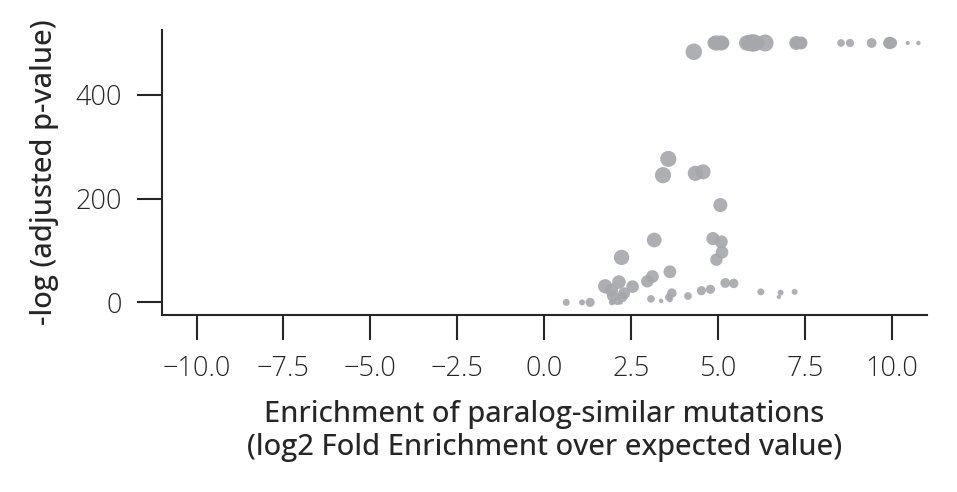

In [157]:
fig, ax1 = plt.subplots(figsize=(3.2, 1.65))

sns.scatterplot(x = A_X,
                y = A_Y,
                s = A_S, 
                color = "#A6A7AA", 
                alpha=0.9,
                ax = ax1)

# sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
#                 data = HHR_SNP_DF.head(2),
#                 s = (np.log(HHR_SNP_DF["NObserved_SNPs_MatchParalogSNP"] / 3 ) * 4).replace(0, 1), 
#                 color = "#DD929B", #s = 5,
#                 alpha=0.8, 
#                 ax = ax1)

# ax1.axvline(x=0, color='#828689',
#              linestyle='solid', linewidth=0.5)

# ax1.axhline(y= 4.605170185988091, color='#828689', linestyle='dashed', linewidth=0.3) 
# ax1.axvline(x= 1,  color='#828689', linestyle='dashed', linewidth=0.3)
# ax1.axvline(x=-1, color='#828689', linestyle='dashed', linewidth=0.3)

ax1.set_xlabel('Enrichment of paralog-similar mutations\n(log2 Fold Enrichment over expected value)',
              fontsize=7)

ax1.set_ylabel('-log (adjusted p-value)', fontsize=7)

ax1.set_xlim(-11, 11)
sns.despine()
plt.show()

# Explore enrichment analysis of SNPs matching paralogs (across all HH Regions)

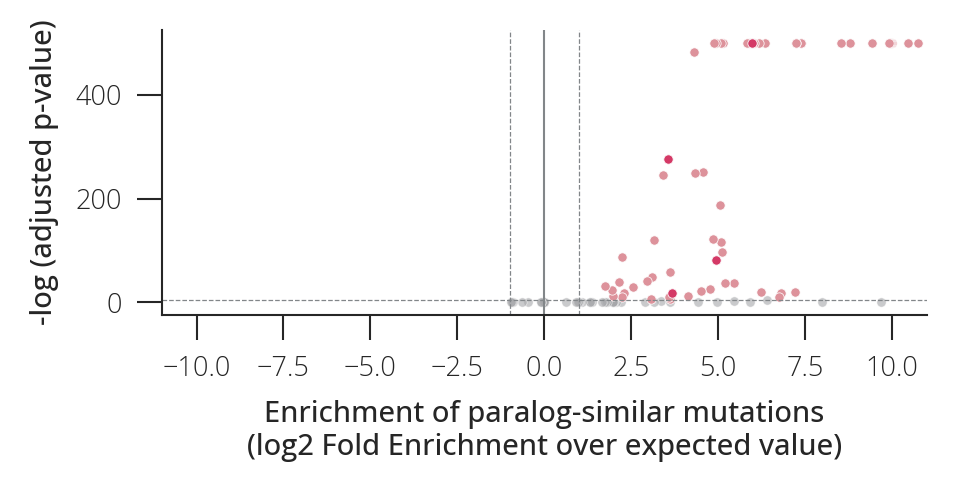

In [158]:
fig, ax1 = plt.subplots(figsize=(3.2, 1.65))
sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
            data = HHR_SNP_NotSig_DF,
           color = "#A6A7AA", s = 5, alpha=0.6,
           ax = ax1)

sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
            data = HHR_SNP_Sig_DF,
           color = "#DD929B", s = 5, alpha=1, 
           ax = ax1)

sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
            data = HHR_SNP_Sig_Selected_DF,
           color = "#D43966", s = 5, alpha=1, 
           ax = ax1)


ax1.axvline(x=0, color='#828689',
             linestyle='solid', linewidth=0.5)

#ax1.axhline(y = -np.log(0.01), color='#828689', linestyle='dashed', linewidth=0.2) 
ax1.axhline(y = 4.605170185988091, color='#828689', linestyle='dashed', linewidth=0.3) 

ax1.axvline(x=1,  color='#828689', linestyle='dashed', linewidth=0.3)
ax1.axvline(x=-1, color='#828689', linestyle='dashed', linewidth=0.3)


ax1.set_xlabel('Enrichment of paralog-similar mutations\n(log2 Fold Enrichment over expected value)',
              fontsize=7)
ax1.set_ylabel('-log (adjusted p-value)', fontsize=7)

ax1.set_xlim(-11, 11)
#ax.set_ylim(-1, 200)
sns.despine()
#plt.savefig('MutAttributes_Plots/HHR.ParalogSNPEnrich.Volcano.V1.pdf')
plt.savefig('MutAttributes_Plots/HHR.ParalogSNPEnrich.Volcano.V1.svg')
plt.show()  

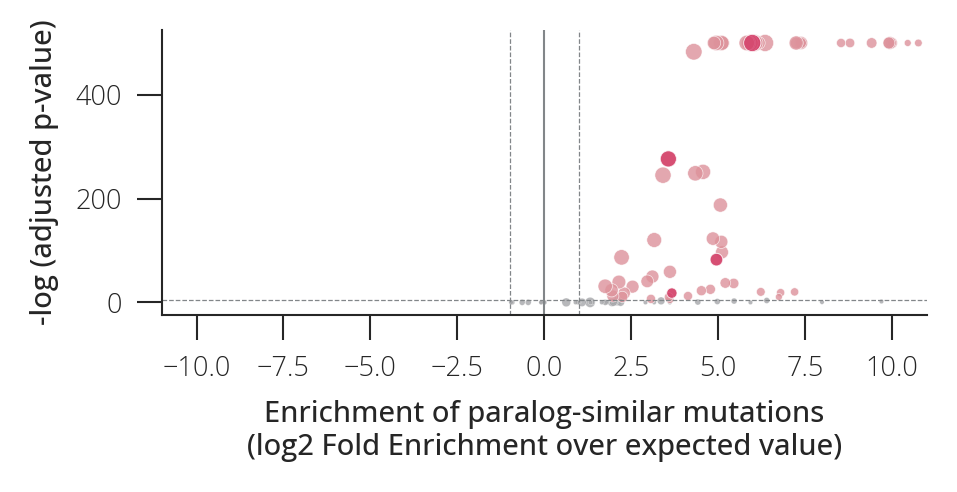

In [159]:
fig, ax1 = plt.subplots(figsize=(3.2, 1.65))

sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
                data = HHR_SNP_NotSig_DF,
                s = (np.log1p(HHR_SNP_NotSig_DF["NObserved_SNPs_MatchParalogSNP"] / 3 ) * 4).replace(0, 1),
                color = "#A6A7AA", 
                alpha=0.8,
                ax = ax1)

sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
                data = HHR_SNP_Sig_DF,
                s = (np.log1p(HHR_SNP_Sig_DF["NObserved_SNPs_MatchParalogSNP"] / 3 ) * 4).replace(0, 1),
                color = "#DD929B", #s = 5,
                alpha=0.8, 
                ax = ax1)

sns.scatterplot(x = 'Log2FoldEnrichment', y = 'neglog_p_corr',
                data = HHR_SNP_Sig_Selected_DF,
                s = (np.log1p(HHR_SNP_Sig_Selected_DF["NObserved_SNPs_MatchParalogSNP"] / 3 ) * 4).replace(0, 1),
                color = "#D43966", #s = 5,
                alpha=0.8, 
                ax = ax1)


ax1.axvline(x=0, color='#828689',
             linestyle='solid', linewidth=0.5)

#ax1.axhline(y = -np.log(0.01), color='#828689', linestyle='dashed', linewidth=0.2) 
ax1.axhline(y = 4.605170185988091, color='#828689', linestyle='dashed', linewidth=0.3) 

ax1.axvline(x=1,  color='#828689', linestyle='dashed', linewidth=0.3)
ax1.axvline(x=-1, color='#828689', linestyle='dashed', linewidth=0.3)

ax1.set_xlabel('Enrichment of paralog-similar mutations\n(log2 Fold Enrichment over expected value)',
              fontsize=7)
ax1.set_ylabel('-log (adjusted p-value)', fontsize=7)

ax1.set_xlim(-11, 11)
#ax1.set_ylim(-20, 540)
sns.despine()
plt.savefig('MutAttributes_Plots/HHR.ParalogSNPEnrich.NSNPsSize.Volcano.V1.svg')
plt.show()

In [160]:
HHR_SNP_Sig_Selected_DF.head(3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
0,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,4275,35,417,215,0.000000e+00,500.000000,500.000000,3.414035,1.000000e-40,500.000000,3,62.975334,1.799170,5.976715,211.585965,1.000000,0.515588
138,179,NC_000962.3,3846460,3847892,3847176.0,1432,"PPE59,Rv3430c",1,2,2,2,179,PR_HmRegion_179,0,PR_Set_48,4296,114,33,27,1.040087e-38,-87.458930,87.458930,0.875698,1.632936e-36,82.402684,1,30.832536,1.489009,4.946382,26.124302,0.125581,0.818182
137,177,NC_000962.3,3841532,3842904,3842218.0,1372,"Rv3424c,PPE57",0,2,2,2,177,PR_HmRegion_177,0,PR_Set_48,4116,170,21,11,1.067762e-10,-22.960286,22.960286,0.867347,1.676386e-08,17.904040,1,12.682353,1.103200,3.664751,10.132653,0.051163,0.523810


In [161]:

T_X = np.array([1, 2, 3, 4, 5, 6, 7])
T_Y = np.array([25, 50, 75, 100, 125, 150, 175])
T_PR_MutCt = np.array([0, 1, 10, 50, 100, 200, 300])

T_S = pd.Series(np.log1p(T_PR_MutCt / 3 ) * 4).replace(0, 1)

print(T_X)
print(T_Y)
print(T_PR_MutCt)
print(T_S)


[1 2 3 4 5 6 7]
[ 25  50  75 100 125 150 175]
[  0   1  10  50 100 200 300]
0     1.000000
1     1.150728
2     5.865348
3    11.486718
4    14.144467
5    16.858375
6    18.460482
dtype: float64


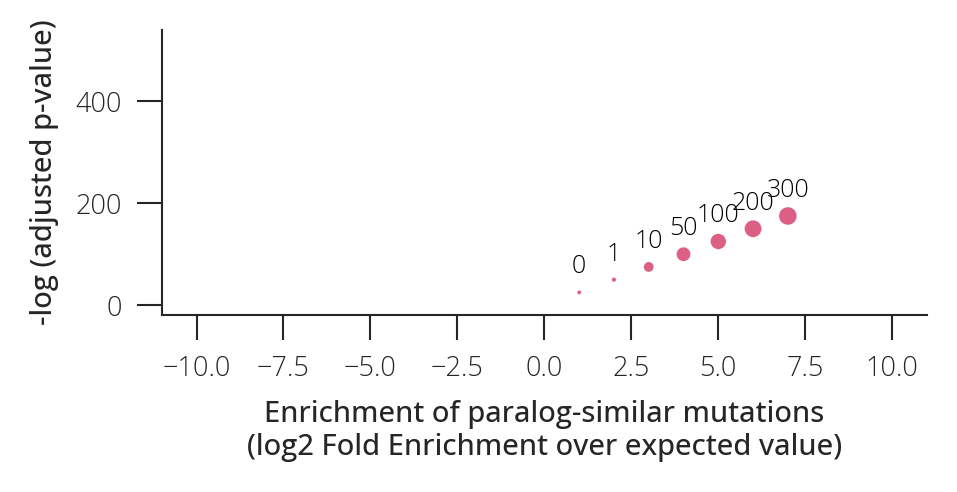

In [162]:

# Create figure
fig, ax1 = plt.subplots(figsize=(3.2, 1.65))

T_X = np.array([1, 2, 3, 4, 5, 6, 7])
T_Y = np.array([25, 50, 75, 100, 125, 150, 175])
T_PR_MutCt = np.array([0, 1, 10, 50, 100, 200, 300])

T_S = pd.Series(np.log1p(T_PR_MutCt / 3 ) * 4).replace(0, 1)

# Scatter plot
sns.scatterplot(x=T_X, y=T_Y, s=T_S, color="#D43966", alpha=0.8, ax=ax1)

# Add text labels for each point
for x, y, label in zip(T_X, T_Y, T_PR_MutCt):
    ax1.text(x, y + 50, str(label), fontsize=6, ha='center', va='center', color='black')

# Labels and limits
ax1.set_xlabel('Enrichment of paralog-similar mutations\n(log2 Fold Enrichment over expected value)', fontsize=7)
ax1.set_ylabel('-log (adjusted p-value)', fontsize=7)
ax1.set_ylim(-20, 540)
ax1.set_xlim(-11, 11)

sns.despine()

# Save figure
plt.savefig('MutAttributes_Plots/Volcano.NSNPs.ExampleSizesForLegend.svg')
plt.show()


### How many of the HHRs detected overlap with a NucDiv hotspots?

In [163]:
HHR_SNP_Sig_DF.shape

(60, 32)

In [164]:
HHR_SNP_Sig_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog
128,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,PR_Set_24,7329,1,17,4,0.0,500.0,500.0,0.00232,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.99768,0.018605,0.235294


In [165]:
HHR_SNP_Sig_DF.query("NucDivHotspot_Ovrlap > 0").shape

(28, 32)

In [166]:
HHR_SNP_Sig_DF.query("NucDivHotspot_Ovrlap == 0").shape

(32, 32)

## How many of the 37 1-kb Diversity hotspots overlap with a HHR w/ an enrichment of paralog SNP mutations? (33/37, 89%) 

In [167]:
NucDiv_HSR_HmSNPs_DF = bf.count_overlaps(NucDiv_HSR_1kb_DF, 
                                         HHR_SNP_Sig_DF ,
                                              cols1 = ("Chrom", "Start", "End"),
                                              cols2 = ("Chr", "Start", "End"))

NucDiv_HSR_HmSNPs_DF.rename(columns={'count': 'OvrlapWiHHR_WiParalogSNPEnrichment'}, inplace=True)
NucDiv_HSR_HmSNPs_DF.shape

(37, 21)

In [168]:
NucDiv_HSR_HmSNPs_DF.query("OvrlapWiHHR_WiParalogSNPEnrichment > 0").shape[0]

33

In [169]:
NucDiv_HSR_HmSNPs_DF.query("OvrlapWiHHR_WiParalogSNPEnrichment == 0")

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap,OvrlapWiHHR_WiParalogSNPEnrichment
16,NC_000962.3,2262000,2263000,0.002305,Rv2015c,2262500.0,2.30490,3.494011,10.302844,True,1,1,0,0,0,0,1,1,1,1,0
17,NC_000962.3,2338000,2339000,0.002556,"Rv2081c,Rv2082",2338500.0,2.55567,3.935328,11.525454,True,1,1,0,0,1,1,1,1,1,1,0
18,NC_000962.3,2339000,2340000,0.002409,Rv2082,2339500.0,2.40884,3.676930,10.809595,True,0,0,0,0,0,0,2,1,1,1,0
24,NC_000962.3,3732000,3733000,0.004223,PPE54,3732500.0,4.22288,6.869360,19.653806,True,1,1,0,0,1,1,1,1,1,1,0


In [170]:
NucDiv_HSR_HmSNPs_DF.query("OvrlapWiHHR_WiParalogSNPEnrichment > 0")

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap,OvrlapWiHHR_WiParalogSNPEnrichment
0,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1,1
1,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1,1
2,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1,1
3,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1,1
4,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1,1
5,NC_000962.3,1096000,1097000,0.004876,"PE_PGRS18,mprA",1096500.0,4.87615,8.019015,22.838773,True,2,1,0,0,1,1,1,1,1,1,1
6,NC_000962.3,1276000,1277000,0.013222,Rv1148c,1276500.0,13.22200,22.706424,63.528313,True,2,1,0,0,0,0,3,1,1,1,1
7,NC_000962.3,1340000,1341000,0.002840,"PPE18,esxK",1340500.0,2.84020,4.436057,12.912657,True,6,1,0,0,0,0,3,1,2,1,2
8,NC_000962.3,1341000,1342000,0.003000,"esxL,Rv1199c",1341500.0,2.99955,4.716488,13.689556,True,9,1,0,0,0,0,1,1,2,1,2
9,NC_000962.3,1533000,1534000,0.002500,"PPE19,Rv1362c",1533500.0,2.50010,3.837533,11.254526,True,2,1,0,0,0,0,1,1,1,1,1


# Extras